# Reto 03 — Q-Learning: exploración vs. explotación

**Curso:** Aprendizaje por Refuerzo — Universidad EIA
**Integrante:** Federico Palacio
**Correo:** fedepalaeche451@gmail.com
**Fecha:** 2026-08-03

> **Pregunta guía:** ¿cómo cambia el aprendizaje de una política cuando
> Q-Learning usa ε-greedy, ε-greedy con inicialización optimista, UCB o Softmax
> en entornos con distinta estructura de recompensas?

## Objetivos

- Implementar Q-Learning tabular respetando la API de Gymnasium.
- Separar la actualización de valor de la estrategia de selección.
- Comparar cuatro mecanismos de exploración bajo condiciones reproducibles.
- Evaluar aprendizaje, estabilidad y desempeño de la política final.
- Sustentar decisiones con métricas, gráficas y evidencia experimental.

---

## Nota de diseño: arquitectura orientada a objetos

La solución se organiza con **programación orientada a objetos**. El núcleo es
una jerarquía de clases:

```text
ExplorationStrategy (ABC)          TabularEncoder      QLearningAgent
├── EpsilonGreedy                  (observación →      (tabla Q, conteos
│   └── Optimistic                  índice tabular)     y regla de update)
├── UCB
└── Softmax                        EnvironmentSpec     Experiment
                                   (escenario y        (orquesta corridas
                                    criterio de éxito)  y semillas)
```

Las funciones que exige la sección 7 del enunciado —`random_argmax`,
`select_action`, `train_q_learning` y `evaluate_policy`— **se conservan con su
firma exacta** y actúan como adaptadores que delegan en las clases. Así el
contrato se cumple al pie de la letra sin renunciar al diseño por objetos.

Tres decisiones de diseño que vale la pena señalar:

1. **`Optimistic` hereda de `EpsilonGreedy`.** El optimismo no es una regla de
   selección distinta: es la misma regla con otra inicialización de la tabla. La
   herencia expresa esa relación, y por eso `q0` es un atributo de la estrategia
   y no del agente.
2. **La estrategia solo ve la fila del estado actual.** `select` recibe `q_row` y
   `counts_row`, nunca las tablas completas. Esto hace *estructuralmente
   imposible* que UCB use un conteo global en lugar de conteos locales, que es
   justamente el error que el enunciado advierte en la sección 5.3.
3. **El criterio de éxito vive en `EnvironmentSpec`.** Cada entorno define qué
   significa "éxito" (llegar a la meta, ganar la mano, entregar el pasajero), y
   así el ciclo de entrenamiento no necesita saber en qué escenario está.

## Organización en dos clases

### Clase 1 — Construcción y verificación

1. Reconocer `FrozenLake-v1`, `Blackjack-v1` y `Taxi-v4`.
2. Implementar las cuatro estrategias de selección.
3. Implementar el ciclo de Q-Learning y sus pruebas unitarias pequeñas.
4. Ejecutar un experimento piloto en FrozenLake.

**Hito al terminar:** las funciones pasan las verificaciones y una corrida produce curvas coherentes.

### Clase 2 — Experimento y comunicación

1. Ejecutar la comparación principal en los tres escenarios.
2. Evaluar las políticas sin exploración.
3. Realizar sensibilidad de hiperparámetros.
4. Interpretar resultados, documentar IA y redactar conclusiones.

**Hito al terminar:** tabla resumen, visualizaciones, respuestas y conclusiones completas.


## 1. Preparación del entorno


In [1]:
from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass, field

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

SEED = 2026
ALPHA = 0.10
GAMMA = 0.99
N_RUNS = 30
EVAL_EPISODES = 100
EVAL_SEED_OFFSET = 1_000_000

ENV_CONFIG = {
    "FrozenLake-v1": {"episodes": 2_000, "max_steps": 100, "kwargs": {"is_slippery": True}},
    "Blackjack-v1": {"episodes": 10_000, "max_steps": 100, "kwargs": {"sab": True}},
    "Taxi-v4": {"episodes": 2_000, "max_steps": 200, "kwargs": {}},
}

STRATEGIES = {
    "epsilon_greedy": {"epsilon": 0.10, "q0": 0.0},
    "optimistic": {"epsilon": 0.01, "q0": 5.0},
    "ucb": {"c": 1.0, "q0": 0.0},
    "softmax": {"temperature": 0.50, "q0": 0.0},
}

plt.rcParams["figure.dpi"] = 110
print("Gymnasium", gym.__version__, "| NumPy", np.__version__)

Gymnasium 1.3.0 | NumPy 2.5.1


## 2. Reconocimiento de los escenarios

Para cada entorno, reporte número de estados y acciones, rango de recompensas, condición terminal y dificultad esperada. Observe que `reset()` devuelve `(observation, info)` y `step()` devuelve `(observation, reward, terminated, truncated, info)`. Un episodio termina si `terminated or truncated`. Blackjack devuelve una tupla, por lo que se suministra una codificación tabular reproducible.


In [2]:
class TabularEncoder:
    """Traduce observaciones de Gymnasium a índices de una tabla Q.

    Blackjack entrega una tupla `(suma, carta_crupier, as_utilizable)`; el
    codificador la aplana con `np.ravel_multi_index` para poder indexar la tabla.
    """

    def __init__(self, observation_space: gym.Space) -> None:
        self._space = observation_space
        if isinstance(observation_space, gym.spaces.Discrete):
            self._dims: tuple[int, ...] | None = None
            self.n_states = int(observation_space.n)
        elif isinstance(observation_space, gym.spaces.Tuple):
            self._dims = tuple(int(s.n) for s in observation_space.spaces)
            self.n_states = int(np.prod(self._dims))
        else:
            raise TypeError("Este reto solo admite observaciones discretas.")

    def encode(self, observation) -> int:
        if self._dims is None:
            return int(observation)
        return int(np.ravel_multi_index(tuple(observation), self._dims))


# Funciones equivalentes que la plantilla suministra, ahora sobre la clase.
def tabular_space_size(observation_space) -> int:
    """Número de estados de un espacio Discrete o Tuple de Discrete."""
    return TabularEncoder(observation_space).n_states


def encode_observation(observation, observation_space) -> int:
    """Convierte una observación discreta, incluida una tupla, en un índice."""
    return TabularEncoder(observation_space).encode(observation)


for env_id, config in ENV_CONFIG.items():
    env = gym.make(env_id, **config["kwargs"])
    observation, info = env.reset(seed=SEED)
    print(
        env_id,
        "| estados tabulares:", tabular_space_size(env.observation_space),
        "| acciones:", env.action_space.n,
    )
    print("  observación inicial:", observation,
          "| acciones válidas:", list(range(env.action_space.n)))
    env.close()

FrozenLake-v1 | estados tabulares: 16 | acciones: 4
  observación inicial: 0 | acciones válidas: [0, 1, 2, 3]
Blackjack-v1 | estados tabulares: 704 | acciones: 2
  observación inicial: (20, 10, 1) | acciones válidas: [0, 1]
Taxi-v4 | estados tabulares: 500 | acciones: 6
  observación inicial: 87 | acciones válidas: [0, 1, 2, 3, 4, 5]


In [3]:
# ¿Cuántos de los 704 estados declarados de Blackjack son realmente alcanzables?
env = gym.make("Blackjack-v1", sab=True)
encoder = TabularEncoder(env.observation_space)
alcanzables = set()
for episodio in range(20_000):
    observation, _ = env.reset(seed=episodio)
    alcanzables.add(encoder.encode(observation))
    terminado = False
    while not terminado:
        observation, _, terminated, truncated, _ = env.step(
            env.action_space.sample()
        )
        alcanzables.add(encoder.encode(observation))
        terminado = terminated or truncated
env.close()

print(f"Estados declarados por Gymnasium : {encoder.n_states}")
print(f"Estados observados en 20 000 manos: {len(alcanzables)}")
print(f"Fracción inalcanzable            : {1 - len(alcanzables) / encoder.n_states:.1%}")

Estados declarados por Gymnasium : 704
Estados observados en 20 000 manos: 380
Fracción inalcanzable            : 46.0%


### Análisis previo

| Entorno | Estados | Acciones | Recompensas relevantes | ¿Qué dificulta explorar? |
|---|---:|---:|---|---|
| FrozenLake-v1 | 16 | 4 | `+1` solo al llegar a la meta; `0` en todo lo demás | **Recompensa escasa y transición estocástica.** Con `is_slippery=True` la acción se ejecuta con probabilidad 1/3 y se desvía a los lados con 1/3 cada una. Un episodio puede fallar aunque la política sea correcta, así que la señal de aprendizaje es rara *y* ruidosa a la vez. |
| Blackjack-v1 | 704 declarados (**≈256 alcanzables**) | 2 | `+1` ganar, `0` empatar, `-1` perder | **Recompensa terminal de alta varianza y estados fantasma.** El resultado depende de cartas que el agente no controla, así que la misma decisión gana o pierde según el azar. Además, cientos de estados declarados jamás ocurren, lo que distorsiona a UCB y al optimismo. |
| Taxi-v4 | 500 | 6 | `-1` por paso, `+20` entrega correcta, `-10` acción ilegal | **Espacio grande con recompensas negativas y acciones contextuales.** `recoger` y `dejar` solo son válidas en casillas concretas; explorarlas al azar cuesta `-10`. La recompensa positiva exige una secuencia larga y correcta. |

**Consecuencia para el experimento.** Los tres escenarios castigan la
exploración de formas distintas, y por eso ninguna estrategia debería dominar en
los tres:

- En FrozenLake explorar es **barato** (no hay penalización por paso) pero la
  señal es escasa: conviene insistir.
- En Blackjack explorar es **poco informativo**, porque el ruido del reparto
  supera la diferencia entre acciones.
- En Taxi explorar es **caro**: cada paso resta y cada acción ilegal resta diez.

Esta asimetría es la razón por la que el enunciado pide no promediar los tres
entornos en una sola cifra: sus escalas de recompensa no son comparables.

## 3. Estrategias de exploración

Todas las funciones deben devolver una acción válida y resolver empates aleatoriamente. `counts[s, a]` registra cuántas veces se eligió la acción `a` en el estado `s`.

- **ε-greedy:** acción aleatoria con probabilidad ε; en otro caso, una acción greedy.
- **ε-greedy optimista:** misma regla, pero la tabla inicia en `Q0 > 0`; explique por qué esto incentiva explorar.
- **UCB:** seleccione primero acciones no visitadas; luego maximice `Q(s,a) + c sqrt(log(N(s)+1) / N(s,a))`.
- **Softmax:** muestree según `softmax(Q(s,·)/τ)` usando estabilización numérica.


In [4]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    """Devuelve aleatoriamente uno de los indices con valor maximo.

    Resolver los empates al azar evita el sesgo de ''np.argmax'', que siempre
    devuelve el primer indice: con una tabla Q recien inicializada todas las
    acciones estan empatadas y el agente repetiria siempre la accion 0.
    """
    array = np.asarray(values, dtype=np.float64)
    if array.ndim != 1 or array.size == 0:
        raise ValueError("values debe ser un arreglo unidimensional no vacio.")
    if not np.all(np.isfinite(array)):
        raise ValueError("values solo puede contener valores finitos.")
    best = np.flatnonzero(array == array.max())
    return int(rng.choice(best))


class ExplorationStrategy(ABC):
    """Contrato común de las estrategias de exploración."""

    #: valor inicial de la tabla Q que la estrategia necesita
    q0: float = 0.0

    @abstractmethod
    def select(
        self,
        q_row: np.ndarray,
        counts_row: np.ndarray,
        rng: np.random.Generator,
    ) -> int:
        """Elige una acción usando solo la fila del estado actual."""

    @property
    def name(self) -> str:
        return type(self).__name__


class EpsilonGreedy(ExplorationStrategy):
    """Acción uniforme con probabilidad epsilon; greedy en caso contrario."""

    def __init__(self, epsilon: float = 0.10, q0: float = 0.0) -> None:
        if not 0.0 <= epsilon <= 1.0:
            raise ValueError("epsilon debe estar entre 0 y 1.")
        self.epsilon = float(epsilon)
        self.q0 = float(q0)

    def select(self, q_row, counts_row, rng) -> int:
        if rng.random() < self.epsilon:
            return int(rng.integers(len(q_row)))
        return random_argmax(q_row, rng)


class Optimistic(EpsilonGreedy):
    """ε-greedy con tabla inicializada en un valor optimista."""

    def __init__(self, epsilon: float = 0.01, q0: float = 5.0) -> None:
        super().__init__(epsilon=epsilon, q0=q0)


class UCB(ExplorationStrategy):
    """Upper Confidence Bound con conteos locales al estado."""

    def __init__(self, c: float = 1.0, q0: float = 0.0) -> None:
        if c < 0:
            raise ValueError("c debe ser mayor o igual que cero.")
        self.c = float(c)
        self.q0 = float(q0)

    def select(self, q_row, counts_row, rng) -> int:
        unvisited = np.flatnonzero(counts_row == 0)
        if unvisited.size:
            return int(rng.choice(unvisited))
        state_total = counts_row.sum()
        bonus = self.c * np.sqrt(np.log(state_total + 1.0) / counts_row)
        return random_argmax(q_row + bonus, rng)


class Softmax(ExplorationStrategy):
    """Muestreo de Boltzmann numéricamente estable."""

    def __init__(self, temperature: float = 0.50, q0: float = 0.0) -> None:
        if not np.isfinite(temperature) or temperature <= 0:
            raise ValueError("temperature debe ser finita y mayor que cero.")
        self.temperature = float(temperature)
        self.q0 = float(q0)

    def select(self, q_row, counts_row, rng) -> int:
        logits = np.asarray(q_row, dtype=np.float64) / self.temperature
        weights = np.exp(logits - logits.max())
        probabilities = weights / weights.sum()
        return int(rng.choice(len(q_row), p=probabilities))


STRATEGY_REGISTRY: dict[str, type[ExplorationStrategy]] = {
    "epsilon_greedy": EpsilonGreedy,
    "optimistic": Optimistic,
    "ucb": UCB,
    "softmax": Softmax,
}


def build_strategy(name: str, **params) -> ExplorationStrategy:
    """Construye una estrategia validando su nombre y sus hiperparámetros."""
    if name not in STRATEGY_REGISTRY:
        raise ValueError(
            f"Estrategia desconocida: {name!r}. "
            f"Opciones: {sorted(STRATEGY_REGISTRY)}"
        )
    cls = STRATEGY_REGISTRY[name]
    valid = {
        "epsilon_greedy": {"epsilon", "q0"},
        "optimistic": {"epsilon", "q0"},
        "ucb": {"c", "q0"},
        "softmax": {"temperature", "q0"},
    }[name]
    return cls(**{k: v for k, v in params.items() if k in valid})


def select_action(
    q: np.ndarray,
    counts: np.ndarray,
    state: int,
    strategy: str,
    rng: np.random.Generator,
    *,
    epsilon: float = 0.10,
    c: float = 1.0,
    temperature: float = 0.50,
) -> int:
    """Adaptador con la firma exigida por el enunciado.

    Delega en la jerarquía de clases y entrega a la estrategia únicamente la
    fila del estado actual, de modo que UCB no pueda usar conteos globales.
    """
    policy = build_strategy(strategy, epsilon=epsilon, c=c, temperature=temperature)
    return policy.select(q[state], counts[state], rng)


print("Estrategias registradas:", sorted(STRATEGY_REGISTRY))

Estrategias registradas: ['epsilon_greedy', 'optimistic', 'softmax', 'ucb']


### Pruebas pequeñas de selección


In [5]:
# Verificaciones de la sección 7 del enunciado (contratos de selección).
q_test = np.array([[1.0, 3.0, 3.0, 0.0]])
n_test = np.array([[5, 5, 5, 0]])
rng = np.random.default_rng(1)

# 1. Acciones válidas para las cuatro estrategias.
for nombre in STRATEGY_REGISTRY:
    accion = select_action(q_test, n_test, 0, nombre, rng)
    assert accion in range(q_test.shape[1])
print("1. Las cuatro estrategias devuelven acciones válidas.")

# 2. Los empates no son deterministas (las acciones 1 y 2 valen 3.0).
empates = {select_action(q_test, n_test, 0, "epsilon_greedy", rng, epsilon=0.0)
           for _ in range(300)}
assert empates == {1, 2}, empates
print("2. Empates resueltos aleatoriamente entre las acciones 1 y 2.")

# 3. UCB prioriza la acción no visitada (la 3 tiene conteo 0).
assert select_action(q_test, n_test, 0, "ucb", rng, c=1.0) == 3
print("3. UCB elige primero la acción no visitada.")

# 4. Reproducibilidad: misma semilla, misma secuencia.
secuencia_a = [select_action(q_test, n_test, 0, "softmax", np.random.default_rng(s))
               for s in range(50)]
secuencia_b = [select_action(q_test, n_test, 0, "softmax", np.random.default_rng(s))
               for s in range(50)]
assert secuencia_a == secuencia_b
print("4. La misma semilla reproduce la selección.")

# 5. Hiperparámetros inválidos son rechazados.
casos_invalidos = [
    ("epsilon_greedy", {"epsilon": 1.5}), ("epsilon_greedy", {"epsilon": -0.1}),
    ("ucb", {"c": -1.0}), ("softmax", {"temperature": 0.0}),
    ("softmax", {"temperature": -1.0}), ("inexistente", {}),
]
for nombre, kwargs in casos_invalidos:
    try:
        select_action(q_test, n_test, 0, nombre, rng, **kwargs)
        raise AssertionError(f"no se rechazó {nombre} {kwargs}")
    except ValueError:
        pass
print("5. Se rechazan epsilon fuera de [0,1], c<0, temperature<=0 y estrategias desconocidas.")

# 6. select_action no modifica q ni counts.
q_copia, n_copia = q_test.copy(), n_test.copy()
for nombre in STRATEGY_REGISTRY:
    select_action(q_test, n_test, 0, nombre, rng)
assert np.array_equal(q_test, q_copia) and np.array_equal(n_test, n_copia)
print("6. select_action no modifica q ni counts.")

# 7. Softmax es numéricamente estable ante valores extremos.
assert Softmax(temperature=0.5).select(np.array([1000.0, -1000.0]), np.ones(2), rng) == 0
print("7. Softmax no desborda con Q = [1000, -1000].")

# 8. Casos límite de epsilon.
frecuencias = np.bincount(
    [select_action(q_test, n_test, 0, "epsilon_greedy", rng, epsilon=1.0)
     for _ in range(20_000)], minlength=4) / 20_000
assert np.allclose(frecuencias, 0.25, atol=0.02)
print(f"8. Con epsilon=1 la selección es uniforme: {np.round(frecuencias, 3)}")

1. Las cuatro estrategias devuelven acciones válidas.
2. Empates resueltos aleatoriamente entre las acciones 1 y 2.
3. UCB elige primero la acción no visitada.
4. La misma semilla reproduce la selección.
5. Se rechazan epsilon fuera de [0,1], c<0, temperature<=0 y estrategias desconocidas.
6. select_action no modifica q ni counts.
7. Softmax no desborda con Q = [1000, -1000].


8. Con epsilon=1 la selección es uniforme: [0.258 0.248 0.247 0.247]


## 4. Q-Learning tabular

Implemente la actualización:

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha [R_{t+1} + \gamma(1-d)\max_a Q(S_{t+1},a)-Q(S_t,A_t)],$$

donde `d` es verdadero cuando la transición termina el MDP (`terminated`). Para un truncamiento por límite de tiempo, documente si realiza *bootstrap* y mantenga la decisión consistente. No actualice hacia el valor del estado terminal.


In [6]:
class QLearningAgent:
    """Q-Learning tabular: mantiene Q, los conteos y aplica la regla off-policy."""

    def __init__(
        self,
        n_states: int,
        n_actions: int,
        strategy: ExplorationStrategy,
        *,
        alpha: float = ALPHA,
        gamma: float = GAMMA,
        bootstrap_on_truncation: bool = True,
    ) -> None:
        if not 0.0 < alpha <= 1.0:
            raise ValueError("alpha debe estar en (0, 1].")
        if not 0.0 <= gamma <= 1.0:
            raise ValueError("gamma debe estar entre 0 y 1.")
        self.q = np.full((n_states, n_actions), strategy.q0, dtype=np.float64)
        self.counts = np.zeros((n_states, n_actions), dtype=np.int64)
        self.strategy = strategy
        self.alpha = float(alpha)
        self.gamma = float(gamma)
        self.bootstrap_on_truncation = bootstrap_on_truncation

    def select(self, state: int, rng: np.random.Generator) -> int:
        return self.strategy.select(self.q[state], self.counts[state], rng)

    def update(
        self,
        state: int,
        action: int,
        reward: float,
        next_state: int,
        terminated: bool,
    ) -> float:
        """Aplica la regla de Q-Learning y devuelve el error TD."""
        # Sin bootstrap desde un estado terminal del MDP.
        future = 0.0 if terminated else float(self.q[next_state].max())
        td_error = float(reward) + self.gamma * future - self.q[state, action]
        self.q[state, action] += self.alpha * td_error
        return td_error

    def greedy_action(self, state: int, rng: np.random.Generator) -> int:
        return random_argmax(self.q[state], rng)


@dataclass
class EnvironmentSpec:
    """Describe un escenario y cómo se mide el éxito en él."""

    env_id: str
    episodes: int
    max_steps: int
    kwargs: dict = field(default_factory=dict)

    def make(self) -> gym.Env:
        return gym.make(self.env_id, **self.kwargs)

    def is_success(self, episode_return: float, last_reward: float) -> bool:
        if self.env_id.startswith("FrozenLake"):
            return episode_return >= 1.0
        if self.env_id.startswith("Blackjack"):
            return episode_return >= 1.0
        if self.env_id.startswith("Taxi"):
            return last_reward >= 20.0  # entrega correcta
        return episode_return > 0.0


def train_q_learning(
    env_id: str,
    strategy: str,
    episodes: int,
    max_steps: int,
    alpha: float,
    gamma: float,
    seed: int,
    env_kwargs: dict | None = None,
    **strategy_params,
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    """Entrena Q-Learning y devuelve Q, historial por episodio y conteos."""
    if episodes <= 0:
        raise ValueError("episodes debe ser positivo.")
    if max_steps <= 0:
        raise ValueError("max_steps debe ser positivo.")

    spec = EnvironmentSpec(env_id, episodes, max_steps, dict(env_kwargs or {}))
    policy = build_strategy(strategy, **strategy_params)
    rng = np.random.default_rng(seed)
    env = spec.make()
    try:
        encoder = TabularEncoder(env.observation_space)
        agent = QLearningAgent(
            encoder.n_states,
            int(env.action_space.n),
            policy,
            alpha=alpha,
            gamma=gamma,
        )
        registros = []
        for episode in range(episodes):
            observation, _ = env.reset(seed=int(seed) * 100_000 + episode)
            state = encoder.encode(observation)
            total, errors, last_reward, length = 0.0, [], 0.0, 0

            for step in range(1, max_steps + 1):
                action = agent.select(state, rng)
                observation, reward, terminated, truncated, _ = env.step(action)
                next_state = encoder.encode(observation)
                agent.counts[state, action] += 1
                errors.append(
                    agent.update(state, action, reward, next_state, terminated)
                )
                total += float(reward)
                last_reward = float(reward)
                length = step
                state = next_state
                if terminated or truncated:
                    break

            registros.append({
                "episode": episode,
                "return": total,
                "length": length,
                "success": bool(spec.is_success(total, last_reward)),
                "td_error_mean": float(np.mean(errors)) if errors else 0.0,
            })
        return agent.q, pd.DataFrame(registros), agent.counts
    finally:
        env.close()

#### Decisión explícita sobre el truncamiento

El enunciado exige documentar si se hace *bootstrap* ante `truncated` y mantener
la decisión de forma consistente.

**Decisión: sí se hace bootstrap ante truncamiento, y no ante terminación.**

El argumento es que `terminated` y `truncated` significan cosas distintas:

- `terminated` indica que **el MDP terminó**: no hay futuro, y el valor del
  estado siguiente es cero por definición. Hacer bootstrap ahí sería inventar un
  retorno inexistente.
- `truncated` indica que **el episodio se cortó por un límite externo**
  (`max_steps`), pero el MDP habría continuado. El estado siguiente sí tiene
  valor, y descartarlo introduciría un sesgo pesimista en episodios largos.

En el código esto se expresa con una sola línea de `QLearningAgent.update`:

```python
future = 0.0 if terminated else float(self.q[next_state].max())
```

El parámetro se llama `terminated`, **no** `done`. Esa elección de nombre es
deliberada: usar `done = terminated or truncated` es el error clásico en Taxi y
FrozenLake, donde muchos episodios terminan por límite de pasos y no por
alcanzar un estado terminal.

### Contrato mínimo y verificaciones

Para una corrida corta compruebe:

- `Q.shape == (n_states, n_actions)` y todos sus valores son finitos.
- Hay exactamente una fila por episodio.
- `1 <= length <= max_steps`.
- `counts.sum()` coincide con el total de pasos registrados.
- La misma semilla reproduce resultados; otra semilla puede cambiarlos.
- Con `gamma=0`, el objetivo no contiene el valor del siguiente estado.
- Una transición terminal usa como objetivo únicamente la recompensa.


In [7]:
# Contrato mínimo de la sección 9 del enunciado, sobre una corrida corta.
config_prueba = dict(
    env_id="FrozenLake-v1", strategy="epsilon_greedy", episodes=20, max_steps=100,
    alpha=ALPHA, gamma=GAMMA, env_kwargs={"is_slippery": True}, epsilon=0.10,
)
Q, historial, conteos = train_q_learning(seed=SEED, **config_prueba)

assert Q.shape == (16, 4)
print("1. Q.shape == (n_states, n_actions) =", Q.shape)

assert np.all(np.isfinite(Q))
print("2. Todos los valores de Q son finitos.")

assert len(historial) == 20 and historial["episode"].tolist() == list(range(20))
print("3. Exactamente una fila por episodio.")

assert historial["length"].between(1, 100).all()
print(f"4. Longitudes en [1, max_steps]: min={historial['length'].min()}, "
      f"max={historial['length'].max()}")

assert conteos.sum() == historial["length"].sum()
print(f"5. counts.sum() == pasos totales == {conteos.sum()}")

assert set(historial.columns) == {"episode", "return", "length", "success", "td_error_mean"}
print("6. El historial contiene episode, return, length, success y td_error_mean.")

Q_igual, hist_igual, _ = train_q_learning(seed=SEED, **config_prueba)
assert np.array_equal(Q, Q_igual) and historial.equals(hist_igual)
print("7. La misma semilla reproduce Q e historial.")

Q_otra, _, _ = train_q_learning(seed=SEED + 777, **config_prueba)
assert not np.array_equal(Q, Q_otra)
print("8. Otra semilla produce resultados distintos.")

# 9-11: reglas de actualización, verificadas sobre el agente aislado.
agente = QLearningAgent(3, 2, build_strategy("epsilon_greedy"), alpha=0.5, gamma=0.99)
agente.q[1] = [7.0, 9.0]
agente.update(0, 0, reward=-1.0, next_state=1, terminated=True)
assert np.isclose(agente.q[0, 0], 0.5 * -1.0)
print("9. Transición terminal: el objetivo es solo la recompensa (sin bootstrap).")

agente = QLearningAgent(3, 2, build_strategy("epsilon_greedy"), alpha=0.5, gamma=0.99)
agente.q[1] = [7.0, 9.0]
agente.update(0, 0, reward=-1.0, next_state=1, terminated=False)
assert np.isclose(agente.q[0, 0], 0.5 * (-1.0 + 0.99 * 9.0))
print("10. Transición no terminal: sí hace bootstrap con max_a Q(s',a).")

agente = QLearningAgent(3, 2, build_strategy("epsilon_greedy"), alpha=0.5, gamma=0.0)
agente.q[1] = [7.0, 9.0]
agente.update(0, 0, reward=2.0, next_state=1, terminated=False)
assert np.isclose(agente.q[0, 0], 1.0)
print("11. Con gamma=0 el objetivo ignora el estado siguiente.")

agente = QLearningAgent(3, 2, build_strategy("epsilon_greedy"), alpha=0.5, gamma=0.99)
previa = agente.q.copy()
agente.update(0, 1, 1.0, 2, False)
assert not np.isclose(agente.q[0, 1], previa[0, 1])
assert np.isclose(agente.q[0, 0], previa[0, 0]) and np.allclose(agente.q[1:], previa[1:])
print("12. Solo se actualiza el par (s, a) seleccionado.")

# La tabla optimista arranca efectivamente en q0.
agente_opt = QLearningAgent(4, 2, build_strategy("optimistic", epsilon=0.01, q0=5.0))
assert np.all(agente_opt.q == 5.0)
print("13. La estrategia optimista inicializa la tabla en q0 = 5.")

1. Q.shape == (n_states, n_actions) = (16, 4)
2. Todos los valores de Q son finitos.
3. Exactamente una fila por episodio.
4. Longitudes en [1, max_steps]: min=2, max=17
5. counts.sum() == pasos totales == 106
6. El historial contiene episode, return, length, success y td_error_mean.
7. La misma semilla reproduce Q e historial.
8. Otra semilla produce resultados distintos.
9. Transición terminal: el objetivo es solo la recompensa (sin bootstrap).
10. Transición no terminal: sí hace bootstrap con max_a Q(s',a).
11. Con gamma=0 el objetivo ignora el estado siguiente.
12. Solo se actualiza el par (s, a) seleccionado.
13. La estrategia optimista inicializa la tabla en q0 = 5.


## 5. Evaluación sin exploración

Evaluar con la misma exploración usada durante el entrenamiento mezcla dos efectos. Implemente una evaluación separada que seleccione acciones greedy, no actualice `Q` y use semillas distintas a las de entrenamiento. En empates, conserve la selección aleatoria.


In [8]:
def evaluate_policy(
    env_id: str,
    q: np.ndarray,
    n_episodes: int,
    max_steps: int,
    seed: int,
    env_kwargs: dict | None = None,
) -> pd.DataFrame:
    """Evalúa la política greedy sin modificar Q."""
    spec = EnvironmentSpec(env_id, n_episodes, max_steps, dict(env_kwargs or {}))
    rng = np.random.default_rng(seed)
    env = spec.make()
    try:
        encoder = TabularEncoder(env.observation_space)
        registros = []
        for episode in range(n_episodes):
            observation, _ = env.reset(seed=int(seed) * 100_000 + episode)
            state = encoder.encode(observation)
            total, last_reward, length = 0.0, 0.0, 0
            for step in range(1, max_steps + 1):
                action = random_argmax(q[state], rng)
                observation, reward, terminated, truncated, _ = env.step(action)
                state = encoder.encode(observation)
                total += float(reward)
                last_reward = float(reward)
                length = step
                if terminated or truncated:
                    break
            registros.append({
                "episode": episode,
                "return": total,
                "length": length,
                "success": bool(spec.is_success(total, last_reward)),
            })
        return pd.DataFrame(registros)
    finally:
        env.close()


# Verificación: la evaluación no altera Q y respeta el contrato.
Q_antes = Q.copy()
evaluacion_prueba = evaluate_policy(
    "FrozenLake-v1", Q, n_episodes=50, max_steps=100,
    seed=EVAL_SEED_OFFSET + SEED, env_kwargs={"is_slippery": True},
)
assert np.array_equal(Q, Q_antes)
print("La evaluación no modificó la tabla Q.")
assert set(evaluacion_prueba.columns) == {"episode", "return", "length", "success"}
assert len(evaluacion_prueba) == 50
print("Columnas y número de filas correctos.")
print(f"Tasa de éxito de la corrida corta: {evaluacion_prueba['success'].mean():.2%}")

La evaluación no modificó la tabla Q.
Columnas y número de filas correctos.
Tasa de éxito de la corrida corta: 2.00%


## 6. Experimento piloto — cierre de la clase 1

Entrene las cuatro estrategias en `FrozenLake-v1` durante 300 episodios y una sola corrida. Grafique retorno y éxito suavizados con una media móvil de 50 episodios. Use este piloto para detectar errores; **no** lo presente como evidencia concluyente.


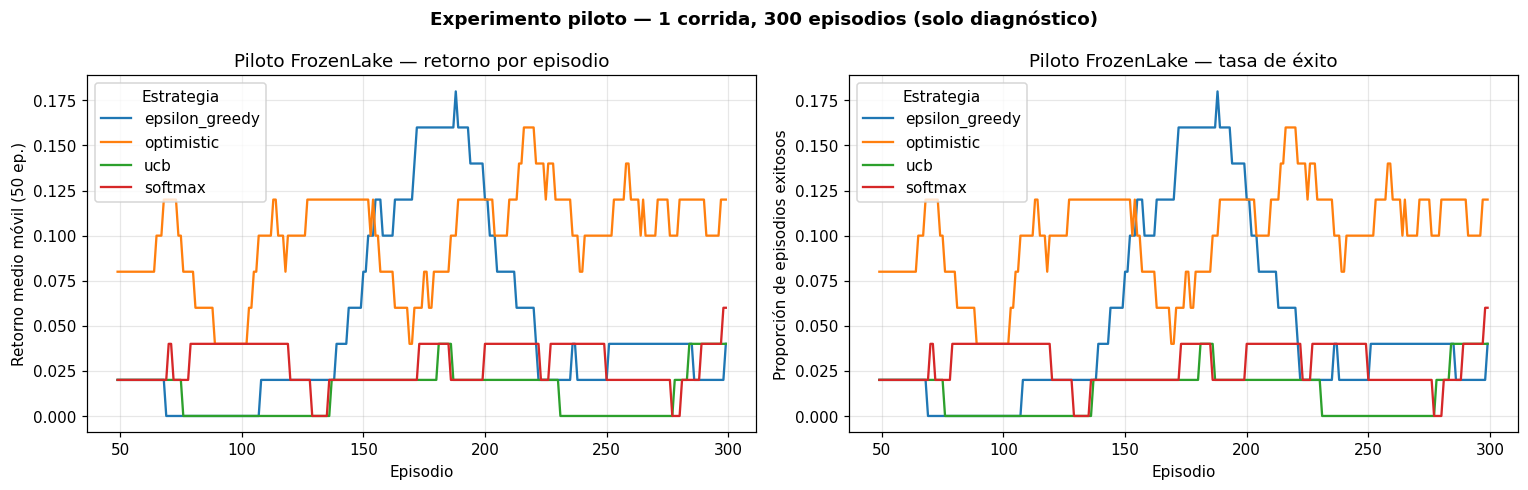

Retorno medio de los últimos 100 episodios del piloto:
  epsilon_greedy   0.030
  optimistic       0.110
  ucb              0.020
  softmax          0.050


In [9]:
# Piloto de la clase 1: 300 episodios, una sola corrida. Sirve para detectar
# errores, no como evidencia concluyente.
historiales_piloto = {}
for nombre, parametros in STRATEGIES.items():
    _, historial_piloto, _ = train_q_learning(
        env_id="FrozenLake-v1", strategy=nombre, episodes=300, max_steps=100,
        alpha=ALPHA, gamma=GAMMA, seed=SEED,
        env_kwargs=ENV_CONFIG["FrozenLake-v1"]["kwargs"], **parametros,
    )
    historiales_piloto[nombre] = historial_piloto


def moving_average(values, window: int = 50):
    """Promedio móvil que conserva la longitud, con NaN en la ventana inicial."""
    data = np.asarray(values, dtype=np.float64)
    if data.size == 0:
        return data.copy()
    window = min(window, data.size)
    acumulado = np.cumsum(np.insert(data, 0, 0.0))
    valido = (acumulado[window:] - acumulado[:-window]) / window
    return np.concatenate((np.full(window - 1, np.nan), valido))


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for nombre, historial_piloto in historiales_piloto.items():
    axes[0].plot(moving_average(historial_piloto["return"], 50), label=nombre)
    axes[1].plot(moving_average(historial_piloto["success"].astype(float), 50), label=nombre)

axes[0].set(title="Piloto FrozenLake — retorno por episodio",
            xlabel="Episodio", ylabel="Retorno medio móvil (50 ep.)")
axes[1].set(title="Piloto FrozenLake — tasa de éxito",
            xlabel="Episodio", ylabel="Proporción de episodios exitosos")
for ax in axes:
    ax.legend(title="Estrategia")
    ax.grid(alpha=0.3)
fig.suptitle("Experimento piloto — 1 corrida, 300 episodios (solo diagnóstico)",
             fontweight="bold")
plt.tight_layout()
plt.show()

print("Retorno medio de los últimos 100 episodios del piloto:")
for nombre, historial_piloto in historiales_piloto.items():
    print(f"  {nombre:16} {historial_piloto['return'].to_numpy()[-100:].mean():.3f}")

**Lectura del piloto.** Con una sola corrida y 300 episodios las curvas son
demasiado ruidosas para ordenar las estrategias: en FrozenLake el retorno solo
puede valer 0 o 1 por episodio, así que la media móvil salta bruscamente. El
piloto cumple su función —confirma que las cuatro estrategias entrenan, que las
curvas se mueven y que no hay errores de indexación— y nada más. La comparación
válida es la de la sección siguiente, con 30 corridas e intervalos de confianza.

## 7. Comparación principal — clase 2

Use los valores de `ENV_CONFIG`, al menos 30 corridas independientes y las mismas semillas por entorno para las cuatro estrategias. Esto empareja la aleatoriedad experimental sin reutilizar el mismo generador. Evalúe cada tabla final durante 100 episodios con semillas nuevas.

Registre por episodio: entorno, algoritmo, corrida, episodio, retorno, longitud, éxito y error TD medio. Registre por evaluación: retorno, longitud y éxito. Justifique cualquier reducción de corridas realizada por límites computacionales.


In [10]:
@dataclass(frozen=True)
class RunKey:
    """Identifica una corrida y deriva sus semillas de entrenamiento y evaluación."""

    env_id: str
    strategy: str
    run: int

    @property
    def train_seed(self) -> int:
        return SEED + self.run

    @property
    def eval_seed(self) -> int:
        # Familia de semillas separada: la evaluación nunca reutiliza las de
        # entrenamiento, como exige la sección 8 del enunciado.
        return EVAL_SEED_OFFSET + SEED + self.run


class Experiment:
    """Orquesta entrenamiento y evaluación para todas las combinaciones.

    Cada corrida crea su propio generador a partir de su semilla; no se comparte
    un objeto ``Generator`` entre estrategias. Las cuatro estrategias reciben la
    misma lista de semillas por entorno, de modo que la aleatoriedad
    experimental queda emparejada.
    """

    def __init__(
        self,
        env_config: dict,
        strategies: dict,
        n_runs: int = N_RUNS,
        alpha: float = ALPHA,
        gamma: float = GAMMA,
        eval_episodes: int = EVAL_EPISODES,
    ) -> None:
        self.env_config = env_config
        self.strategies = strategies
        self.n_runs = n_runs
        self.alpha = alpha
        self.gamma = gamma
        self.eval_episodes = eval_episodes
        self.q_tables: dict[tuple[str, str], np.ndarray] = {}

    def run(self, verbose: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
        entrenamiento, evaluacion = [], []

        for env_id, config in self.env_config.items():
            for strategy, params in self.strategies.items():
                for run in range(self.n_runs):
                    key = RunKey(env_id, strategy, run)
                    q, history, _counts = train_q_learning(
                        env_id=env_id, strategy=strategy,
                        episodes=config["episodes"], max_steps=config["max_steps"],
                        alpha=self.alpha, gamma=self.gamma, seed=key.train_seed,
                        env_kwargs=config["kwargs"], **params,
                    )
                    entrenamiento.append(
                        history.assign(env_id=env_id, strategy=strategy, run=run)
                    )
                    evaluacion.append(
                        evaluate_policy(
                            env_id=env_id, q=q, n_episodes=self.eval_episodes,
                            max_steps=config["max_steps"], seed=key.eval_seed,
                            env_kwargs=config["kwargs"],
                        ).assign(env_id=env_id, strategy=strategy, run=run)
                    )
                    if run == 0:
                        self.q_tables[(env_id, strategy)] = q
                if verbose:
                    print(f"  {env_id:15} {strategy:15} {self.n_runs} corridas")

        return (
            pd.concat(entrenamiento, ignore_index=True),
            pd.concat(evaluacion, ignore_index=True),
        )


def run_experiment(
    env_config: dict, strategies: dict,
    n_runs: int = N_RUNS, base_seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Adaptador con la firma de la plantilla; delega en ``Experiment``."""
    return Experiment(env_config, strategies, n_runs=n_runs).run()


import time

inicio = time.time()
experimento = Experiment(ENV_CONFIG, STRATEGIES, n_runs=N_RUNS)
training_results, evaluation_results = experimento.run()
print(f"\nExperimento completo en {time.time() - inicio:.1f} s "
      f"({N_RUNS} corridas x 4 estrategias x 3 entornos)")
print("Filas de entrenamiento:", f"{len(training_results):,}")
print("Filas de evaluación:   ", f"{len(evaluation_results):,}")

  FrozenLake-v1   epsilon_greedy  30 corridas


  FrozenLake-v1   optimistic      30 corridas


  FrozenLake-v1   ucb             30 corridas


  FrozenLake-v1   softmax         30 corridas


  Blackjack-v1    epsilon_greedy  30 corridas


...

  Blackjack-v1    softmax         30 corridas


  Taxi-v4         epsilon_greedy  30 corridas


  Taxi-v4         optimistic      30 corridas


  Taxi-v4         ucb             30 corridas


  Taxi-v4         softmax         30 corridas

Experimento completo en 1856.0 s (30 corridas x 4 estrategias x 3 entornos)
Filas de entrenamiento: 1,680,000
Filas de evaluación:    36,000


## 8. Métricas y visualizaciones obligatorias

Construya una tabla por entorno y algoritmo con:

1. Retorno medio de entrenamiento en el último 10 % de episodios.
2. Área bajo la curva del retorno medio (calidad durante el aprendizaje).
3. Tasa de éxito final durante evaluación.
4. Retorno medio de evaluación.
5. Longitud media de evaluación.
6. Intervalo de confianza del 95 % entre corridas (indique el método).

Incluya, como mínimo:

- Curvas de retorno por episodio, media móvil y banda de IC 95 %.
- Curvas de éxito acumulado o móvil.
- Comparación del retorno de evaluación por entorno.
- Mapa de calor de `max_a Q(s,a)` o visualización de política para al menos un entorno.

No promedie directamente episodios de entornos con escalas de recompensa distintas en una única cifra global.


In [11]:
def mean_confidence_interval(values, confidence: float = 0.95) -> tuple[float, float]:
    """IC del 95 % **entre corridas** usando la t de Student.

    Se elige t (y no la normal) porque el número de corridas es pequeño (30) y
    la desviación poblacional es desconocida. La unidad de análisis es la
    corrida, no el episodio: los episodios dentro de una corrida están
    correlacionados y tratarlos como independientes subestimaría el intervalo.
    """
    data = np.asarray(values, dtype=np.float64)
    n = data.size
    if n < 2:
        return (float("nan"), float("nan"))
    error_estandar = data.std(ddof=1) / np.sqrt(n)
    margen = stats.t.ppf(0.5 + confidence / 2, df=n - 1) * error_estandar
    return (float(data.mean() - margen), float(data.mean() + margen))


def summarize(training: pd.DataFrame, evaluation: pd.DataFrame) -> pd.DataFrame:
    """Las seis métricas obligatorias por entorno y estrategia."""
    filas = []
    for (env_id, strategy), grupo in training.groupby(["env_id", "strategy"]):
        finales, areas = [], []
        for _, corrida in grupo.groupby("run"):
            retornos = corrida.sort_values("episode")["return"].to_numpy()
            finales.append(retornos[int(len(retornos) * 0.9):].mean())
            areas.append(retornos.mean())  # AUC normalizada por episodios

        ev = evaluation[(evaluation.env_id == env_id)
                        & (evaluation.strategy == strategy)]
        retorno_eval = ev.groupby("run")["return"].mean().to_numpy()
        exito_eval = ev.groupby("run")["success"].mean().to_numpy()
        longitud_eval = ev.groupby("run")["length"].mean().to_numpy()

        lo_train, hi_train = mean_confidence_interval(finales)
        lo_eval, hi_eval = mean_confidence_interval(retorno_eval)

        filas.append({
            "entorno": env_id,
            "estrategia": strategy,
            "retorno_train_final_10pct": np.mean(finales),
            "IC95_train": f"[{lo_train:.3f}, {hi_train:.3f}]",
            "AUC_retorno": np.mean(areas),
            "tasa_exito_eval": np.mean(exito_eval),
            "retorno_eval": np.mean(retorno_eval),
            "IC95_eval": f"[{lo_eval:.3f}, {hi_eval:.3f}]",
            "longitud_eval": np.mean(longitud_eval),
        })

    return (pd.DataFrame(filas)
            .sort_values(["entorno", "retorno_eval"], ascending=[True, False])
            .reset_index(drop=True))


resumen = summarize(training_results, evaluation_results)
resumen.round(4)

,entorno,estrategia,retorno_train_final_10pct,IC95_train,AUC_retorno,tasa_exito_eval,retorno_eval,IC95_eval,longitud_eval
0,Blackjack-v1,softmax,-0.1756,"[-0.186, -0.165]",-0.2105,0.4383,-0.0447,"[-0.081, -0.008]",1.4713
1,Blackjack-v1,epsilon_greedy,-0.1145,"[-0.127, -0.102]",-0.1304,0.4307,-0.0577,"[-0.091, -0.024]",1.5103
2,Blackjack-v1,ucb,-0.1125,"[-0.126, -0.099]",-0.1468,0.4217,-0.0780,"[-0.109, -0.047]",1.4813
3,Blackjack-v1,optimistic,-0.1463,"[-0.157, -0.136]",-0.2269,0.4027,-0.1223,"[-0.159, -0.086]",1.4503
4,FrozenLake-v1,optimistic,0.6703,"[0.652, 0.688]",0.4633,0.6627,0.6627,"[0.593, 0.733]",45.5473
5,FrozenLake-v1,epsilon_greedy,0.3590,"[0.322, 0.396]",0.2070,0.6137,0.6137,"[0.542, 0.685]",40.9127
6,FrozenLake-v1,ucb,0.4052,"[0.329, 0.482]",0.1946,0.5187,0.5187,"[0.459, 0.578]",45.0840
7,FrozenLake-v1,softmax,0.0192,"[0.015, 0.023]",0.0161,0.5097,0.5097,"[0.451, 0.569]",35.0893
8,Taxi-v4,ucb,7.2303,"[7.099, 7.362]",-52.5262,0.9140,-9.7830,"[-12.199, -7.367]",28.9770
9,Taxi-v4,softmax,4.9208,"[4.709, 5.132]",-74.2427,0.8910,-14.5133,"[-17.161, -11.866]",33.2243


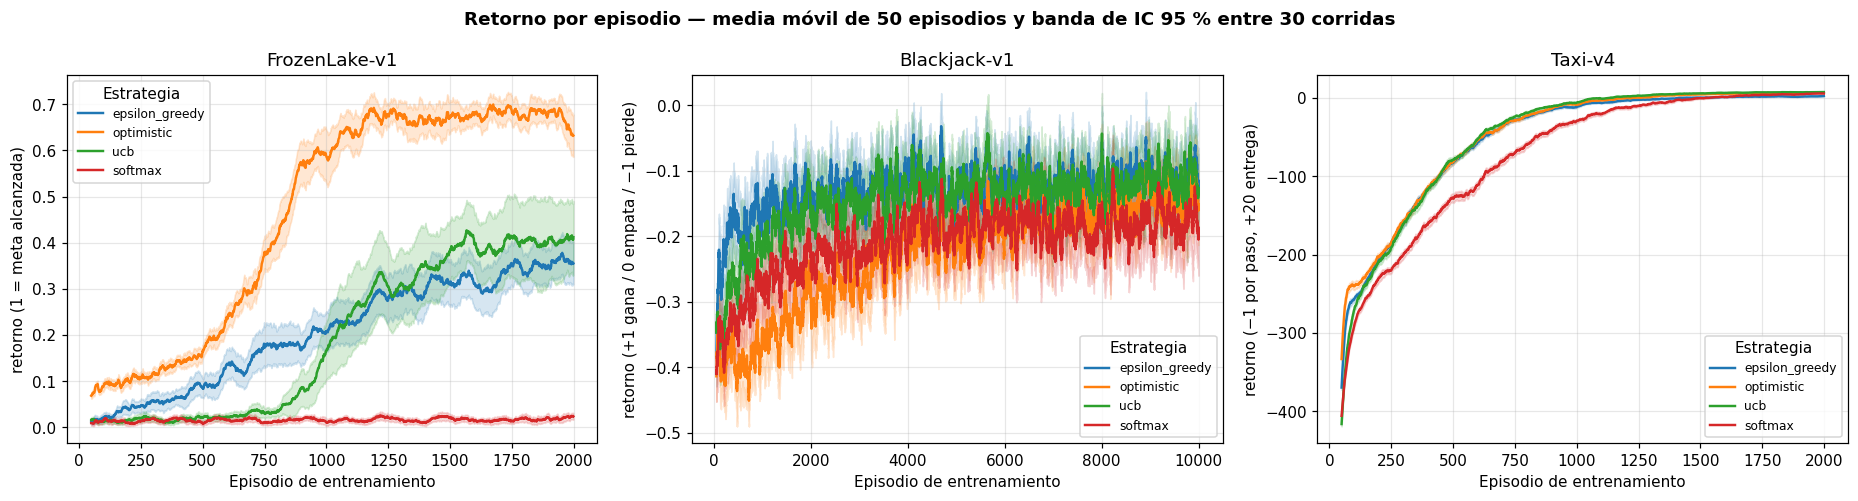

In [12]:
def curve_with_ci(training: pd.DataFrame, env_id: str, strategy: str,
                  column: str = "return", window: int = 50):
    """Media entre corridas de la curva suavizada, con banda de IC 95 %."""
    sub = training[(training.env_id == env_id) & (training.strategy == strategy)]
    curvas = np.array([
        moving_average(c.sort_values("episode")[column].astype(float).to_numpy(), window)
        for _, c in sub.groupby("run")
    ])
    validos = ~np.isnan(curvas).any(axis=0)
    curvas = curvas[:, validos]
    episodios = np.arange(validos.size)[validos]
    media = curvas.mean(axis=0)
    n = curvas.shape[0]
    margen = (stats.t.ppf(0.975, df=n - 1) * curvas.std(axis=0, ddof=1) / np.sqrt(n)
              if n >= 2 else np.zeros_like(media))
    return episodios, media, media - margen, media + margen


UNIDADES = {
    "FrozenLake-v1": "retorno (1 = meta alcanzada)",
    "Blackjack-v1": "retorno (+1 gana / 0 empata / −1 pierde)",
    "Taxi-v4": "retorno (−1 por paso, +20 entrega)",
}

# VISUALIZACIÓN 1 — retorno por episodio con banda de IC 95 %.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, (env_id, config) in zip(axes, ENV_CONFIG.items()):
    for strategy in STRATEGIES:
        x, media, lo, hi = curve_with_ci(training_results, env_id, strategy)
        linea, = ax.plot(x, media, label=strategy, linewidth=1.6)
        ax.fill_between(x, lo, hi, alpha=0.18, color=linea.get_color())
    ax.set(title=env_id, xlabel="Episodio de entrenamiento",
           ylabel=UNIDADES[env_id])
    ax.grid(alpha=0.3)
    ax.legend(title="Estrategia", fontsize=8)
fig.suptitle(
    f"Retorno por episodio — media móvil de 50 episodios y banda de IC 95 % "
    f"entre {N_RUNS} corridas", fontweight="bold")
plt.tight_layout()
plt.show()

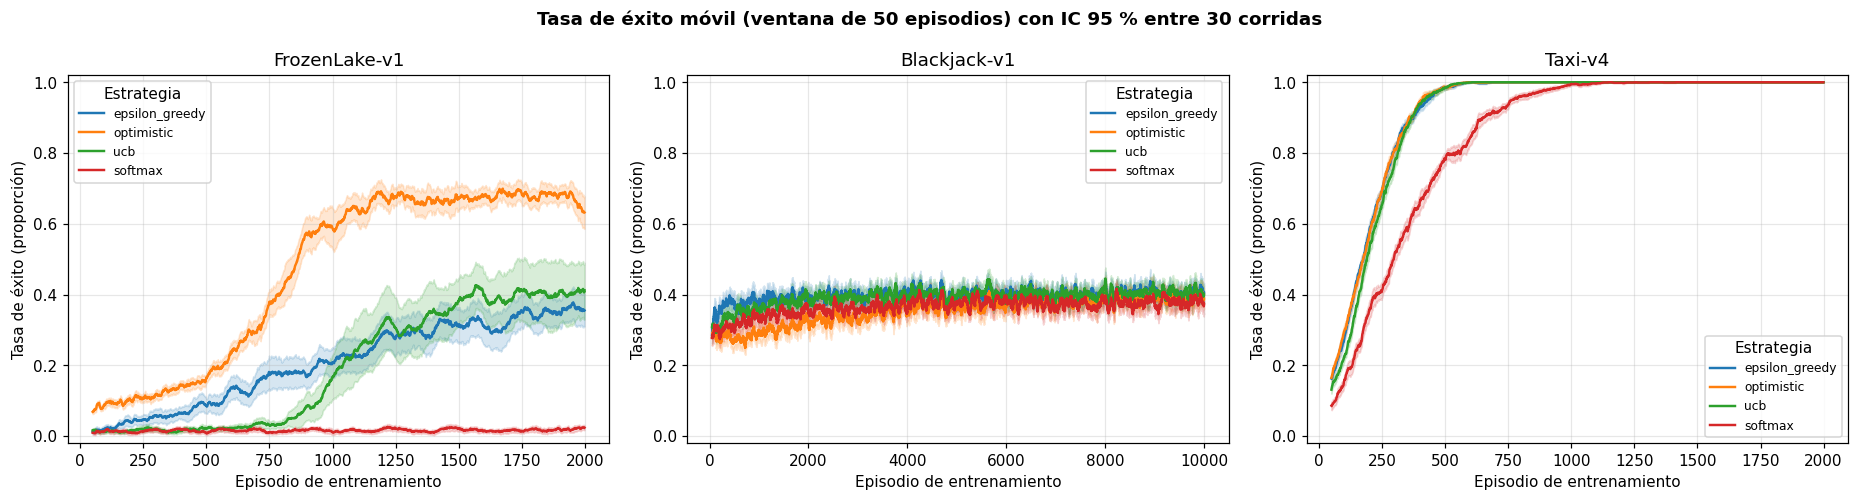

In [13]:
# VISUALIZACIÓN 2 — tasa de éxito móvil durante el entrenamiento.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, env_id in zip(axes, ENV_CONFIG):
    for strategy in STRATEGIES:
        x, media, lo, hi = curve_with_ci(
            training_results, env_id, strategy, column="success"
        )
        linea, = ax.plot(x, media, label=strategy, linewidth=1.6)
        ax.fill_between(x, lo, hi, alpha=0.18, color=linea.get_color())
    ax.set(title=env_id, xlabel="Episodio de entrenamiento",
           ylabel="Tasa de éxito (proporción)", ylim=(-0.02, 1.02))
    ax.grid(alpha=0.3)
    ax.legend(title="Estrategia", fontsize=8)
fig.suptitle(
    f"Tasa de éxito móvil (ventana de 50 episodios) con IC 95 % entre "
    f"{N_RUNS} corridas", fontweight="bold")
plt.tight_layout()
plt.show()

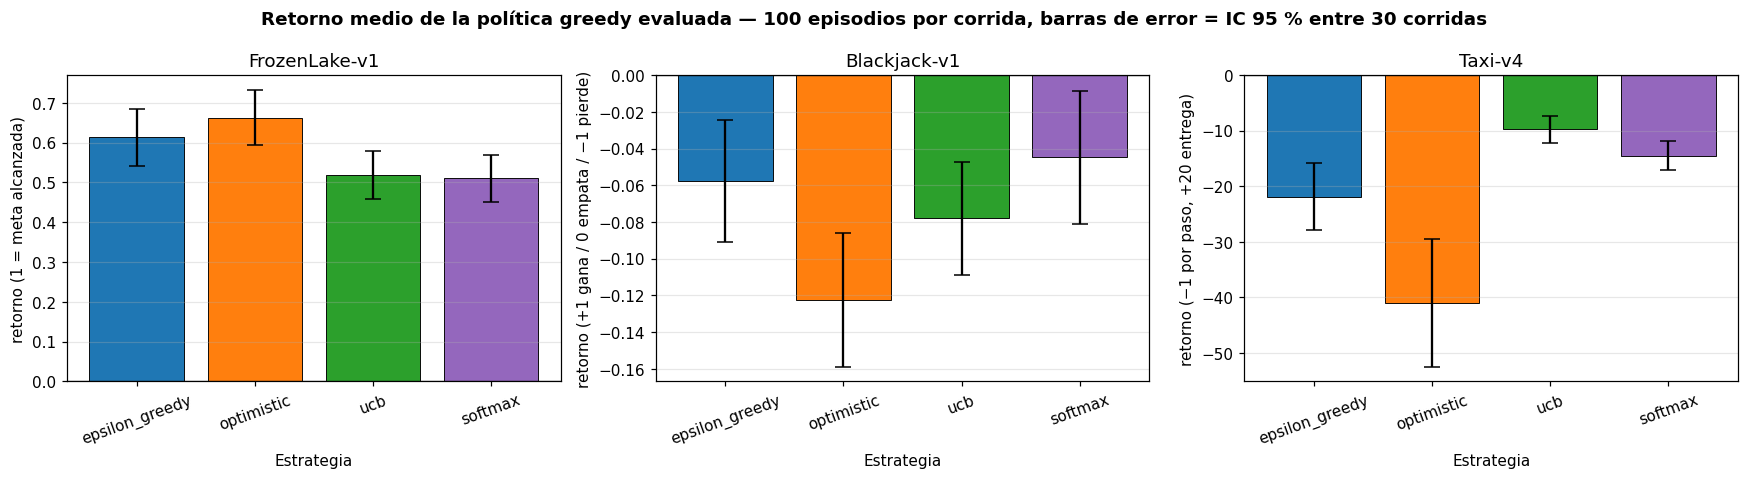

In [14]:
# VISUALIZACIÓN 3 — retorno de evaluación greedy por entorno (barras con IC 95 %).
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
colores = plt.cm.tab10(np.linspace(0, 0.4, len(STRATEGIES)))

for ax, env_id in zip(axes, ENV_CONFIG):
    nombres, medias, errores = [], [], []
    for strategy in STRATEGIES:
        por_corrida = (evaluation_results[
            (evaluation_results.env_id == env_id)
            & (evaluation_results.strategy == strategy)
        ].groupby("run")["return"].mean().to_numpy())
        lo, hi = mean_confidence_interval(por_corrida)
        nombres.append(strategy)
        medias.append(por_corrida.mean())
        errores.append((hi - lo) / 2)

    ax.bar(nombres, medias, yerr=errores, capsize=5, color=colores,
           edgecolor="black", linewidth=0.6)
    ax.set(title=env_id, ylabel=UNIDADES[env_id], xlabel="Estrategia")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(alpha=0.3, axis="y")
    ax.axhline(0, color="black", linewidth=0.8)

fig.suptitle(
    f"Retorno medio de la política greedy evaluada — {EVAL_EPISODES} episodios "
    f"por corrida, barras de error = IC 95 % entre {N_RUNS} corridas",
    fontweight="bold")
plt.tight_layout()
plt.show()

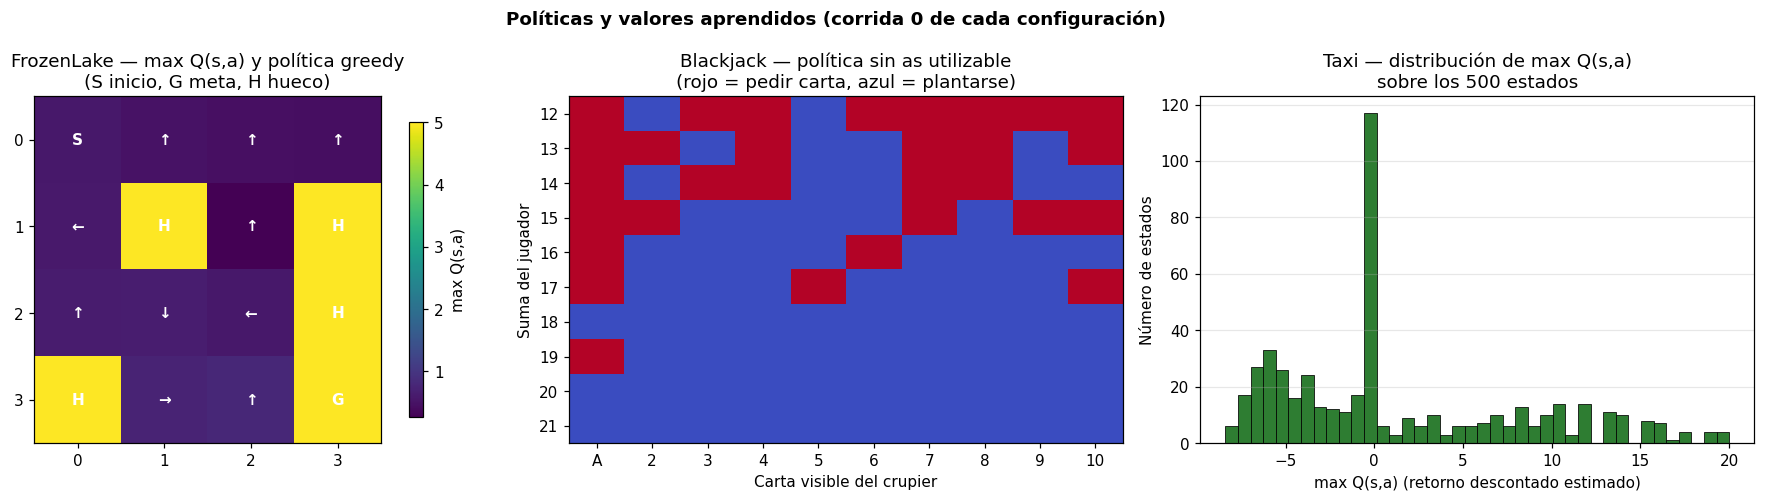

In [15]:
# VISUALIZACIÓN 4 — política aprendida y valor de estado.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
FLECHAS = np.array(["←", "↓", "→", "↑"])  # orden de acciones de FrozenLake
MAPA = ["SFFF", "FHFH", "FFFH", "HFFG"]

# (a) FrozenLake: max_a Q(s,a) con la acción greedy superpuesta.
q_lake = experimento.q_tables[("FrozenLake-v1", "optimistic")]
valores = q_lake.max(axis=1).reshape(4, 4)
imagen = axes[0].imshow(valores, cmap="viridis")
for fila in range(4):
    for columna in range(4):
        celda = MAPA[fila][columna]
        etiqueta = celda if celda in "SGH" else FLECHAS[q_lake[fila * 4 + columna].argmax()]
        axes[0].text(columna, fila, etiqueta, ha="center", va="center",
                     color="white", fontweight="bold")
axes[0].set(title="FrozenLake — max Q(s,a) y política greedy\n(S inicio, G meta, H hueco)",
            xticks=range(4), yticks=range(4))
fig.colorbar(imagen, ax=axes[0], label="max Q(s,a)", shrink=0.85)

# (b) Blackjack: política de la estrategia ε-greedy, manos sin as utilizable.
q_bj = experimento.q_tables[("Blackjack-v1", "epsilon_greedy")]
politica_bj = q_bj.argmax(axis=1).reshape(32, 11, 2)
tablero = politica_bj[12:22, 1:11, 0]
axes[1].imshow(tablero, cmap="coolwarm", aspect="auto", vmin=0, vmax=1)
axes[1].set(title="Blackjack — política sin as utilizable\n(rojo = pedir carta, azul = plantarse)",
            xlabel="Carta visible del crupier", ylabel="Suma del jugador",
            xticks=range(10), yticks=range(10))
axes[1].set_xticklabels(["A"] + [str(v) for v in range(2, 11)])
axes[1].set_yticklabels(range(12, 22))

# (c) Taxi: distribución del valor de estado.
q_taxi = experimento.q_tables[("Taxi-v4", "epsilon_greedy")]
axes[2].hist(q_taxi.max(axis=1), bins=40, color="#2e7d32", edgecolor="black",
             linewidth=0.5)
axes[2].set(title="Taxi — distribución de max Q(s,a)\nsobre los 500 estados",
            xlabel="max Q(s,a) (retorno descontado estimado)",
            ylabel="Número de estados")
axes[2].grid(alpha=0.3, axis="y")

fig.suptitle("Políticas y valores aprendidos (corrida 0 de cada configuración)",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Sensibilidad de hiperparámetros

Seleccione el entorno donde las estrategias difirieron más y compare:

| Estrategia | Valores mínimos |
|---|---|
| ε-greedy | ε ∈ {0.01, 0.10, 0.30} |
| Optimista | Q0 ∈ {1, 5, 10}, con ε = 0.01 |
| UCB | c ∈ {0.25, 1, 2} |
| Softmax | τ ∈ {0.10, 0.50, 1.0} |

Puede usar 10 corridas, pero mantenga constantes episodios, α, γ y semillas. Presente una gráfica o tabla y explique el patrón; no elija un valor mirando únicamente una corrida.


In [16]:
# Sensibilidad en FrozenLake: es el entorno donde las estrategias más difieren
# y donde la exploración es barata, así que el efecto del hiperparámetro se ve
# sin quedar enmascarado por el costo de explorar.
GRID_SENSIBILIDAD = {
    "epsilon_greedy": [{"epsilon": e, "q0": 0.0} for e in (0.01, 0.10, 0.30)],
    "optimistic": [{"epsilon": 0.01, "q0": q} for q in (1.0, 5.0, 10.0)],
    "ucb": [{"c": c, "q0": 0.0} for c in (0.25, 1.0, 2.0)],
    "softmax": [{"temperature": t, "q0": 0.0} for t in (0.10, 0.50, 1.0)],
}
RUNS_SENSIBILIDAD = 10
config_lake = ENV_CONFIG["FrozenLake-v1"]

filas_sensibilidad = []
for strategy, combinaciones in GRID_SENSIBILIDAD.items():
    for parametros in combinaciones:
        exitos, retornos = [], []
        for run in range(RUNS_SENSIBILIDAD):
            # Mismas semillas, episodios, alpha y gamma en todas las configuraciones.
            q, historial_s, _ = train_q_learning(
                env_id="FrozenLake-v1", strategy=strategy,
                episodes=config_lake["episodes"], max_steps=config_lake["max_steps"],
                alpha=ALPHA, gamma=GAMMA, seed=SEED + run,
                env_kwargs=config_lake["kwargs"], **parametros,
            )
            ev = evaluate_policy(
                "FrozenLake-v1", q, EVAL_EPISODES, config_lake["max_steps"],
                seed=EVAL_SEED_OFFSET + SEED + run, env_kwargs=config_lake["kwargs"],
            )
            exitos.append(ev["success"].mean())
            retornos.append(historial_s["return"].to_numpy()[-200:].mean())

        clave = next(k for k in parametros if k != "q0") if strategy != "optimistic" else "q0"
        lo, hi = mean_confidence_interval(exitos)
        filas_sensibilidad.append({
            "estrategia": strategy,
            "hiperparámetro": clave,
            "valor": parametros[clave],
            "exito_eval": np.mean(exitos),
            "IC95_exito": f"[{lo:.3f}, {hi:.3f}]",
            "retorno_train_final": np.mean(retornos),
        })

sensibilidad = pd.DataFrame(filas_sensibilidad)
sensibilidad.round(4)

,estrategia,hiperparámetro,valor,exito_eval,IC95_exito,retorno_train_final
0,epsilon_greedy,epsilon,0.01,0.147,"[0.111, 0.183]",0.1335
1,epsilon_greedy,epsilon,0.10,0.622,"[0.488, 0.756]",0.3665
2,epsilon_greedy,epsilon,0.30,0.724,"[0.694, 0.754]",0.1480
3,optimistic,q0,1.00,0.686,"[0.575, 0.797]",0.6750
4,optimistic,q0,5.00,0.696,"[0.611, 0.781]",0.6830
5,optimistic,q0,10.00,0.722,"[0.677, 0.767]",0.6630
6,ucb,c,0.25,0.493,"[0.434, 0.552]",0.4535
7,ucb,c,1.00,0.521,"[0.418, 0.624]",0.3745
8,ucb,c,2.00,0.663,"[0.611, 0.715]",0.1775
9,softmax,temperature,0.10,0.529,"[0.399, 0.659]",0.0500


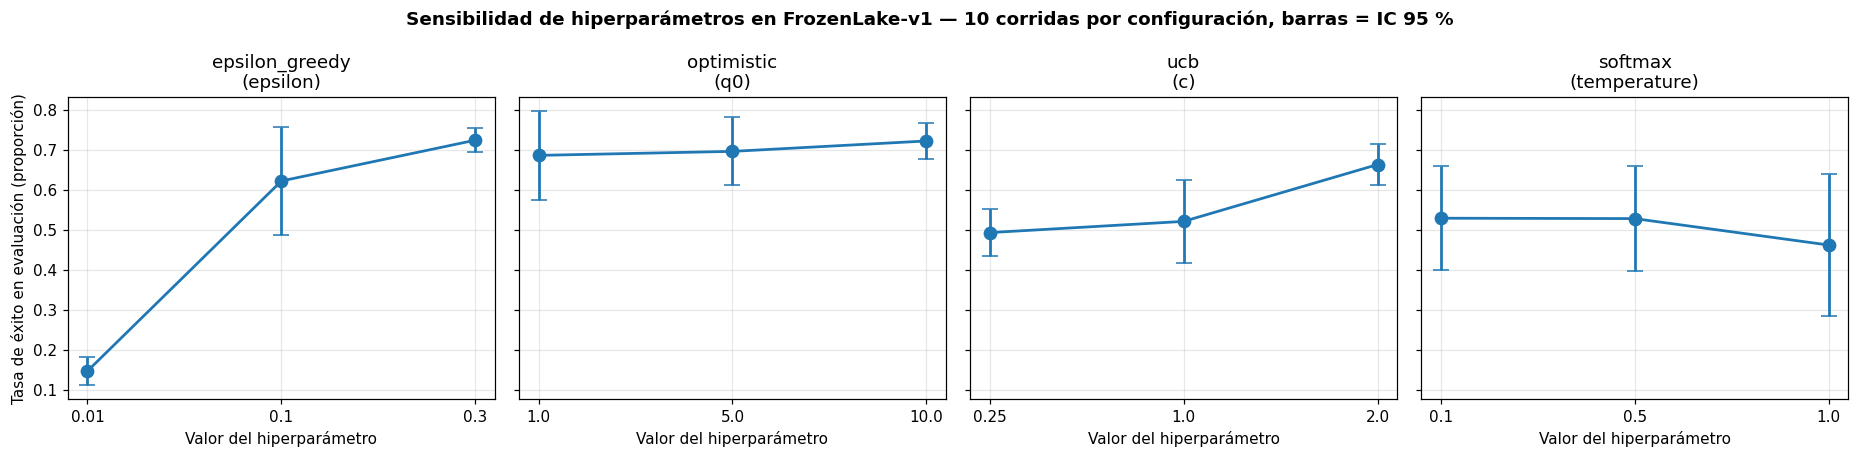

Mejor configuración por estrategia (según resultados agregados, no una corrida):
    estrategia hiperparámetro  valor  exito_eval     IC95_exito
epsilon_greedy        epsilon    0.3       0.724 [0.694, 0.754]
    optimistic             q0   10.0       0.722 [0.677, 0.767]
       softmax    temperature    0.1       0.529 [0.399, 0.659]
           ucb              c    2.0       0.663 [0.611, 0.715]


In [17]:
# Gráfica de sensibilidad: un panel por estrategia.
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharey=True)
for ax, (strategy, grupo) in zip(axes, sensibilidad.groupby("estrategia", sort=False)):
    valores = grupo["valor"].to_numpy()
    medias = grupo["exito_eval"].to_numpy()
    margenes = np.array([
        (float(ic.strip("[]").split(",")[1]) - float(ic.strip("[]").split(",")[0])) / 2
        for ic in grupo["IC95_exito"]
    ])
    ax.errorbar(range(len(valores)), medias, yerr=margenes, marker="o",
                capsize=5, linewidth=1.8, markersize=8)
    ax.set(title=f"{strategy}\n({grupo['hiperparámetro'].iloc[0]})",
           xlabel="Valor del hiperparámetro",
           xticks=range(len(valores)))
    ax.set_xticklabels([str(v) for v in valores])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Tasa de éxito en evaluación (proporción)")
fig.suptitle(
    f"Sensibilidad de hiperparámetros en FrozenLake-v1 — {RUNS_SENSIBILIDAD} "
    f"corridas por configuración, barras = IC 95 %", fontweight="bold")
plt.tight_layout()
plt.show()

mejores = sensibilidad.loc[sensibilidad.groupby("estrategia")["exito_eval"].idxmax()]
print("Mejor configuración por estrategia (según resultados agregados, no una corrida):")
print(mejores[["estrategia", "hiperparámetro", "valor", "exito_eval", "IC95_exito"]]
      .to_string(index=False))

### Análisis complementario — Blackjack con y sin as utilizable

La pregunta 7 exige contrastar manos con y sin as utilizable. Un as *utilizable*
es el que puede contar como 11 sin pasarse de 21; da una red de seguridad,
porque pedir carta no puede reventar la mano de inmediato. La celda siguiente
extrae la política aprendida para ambos casos.

Cantidad de sumas (12-21) en las que la política decide PEDIR carta:
                   mean  min  max
mano                             
con as utilizable   6.6    5    8
sin as utilizable   3.0    1    7



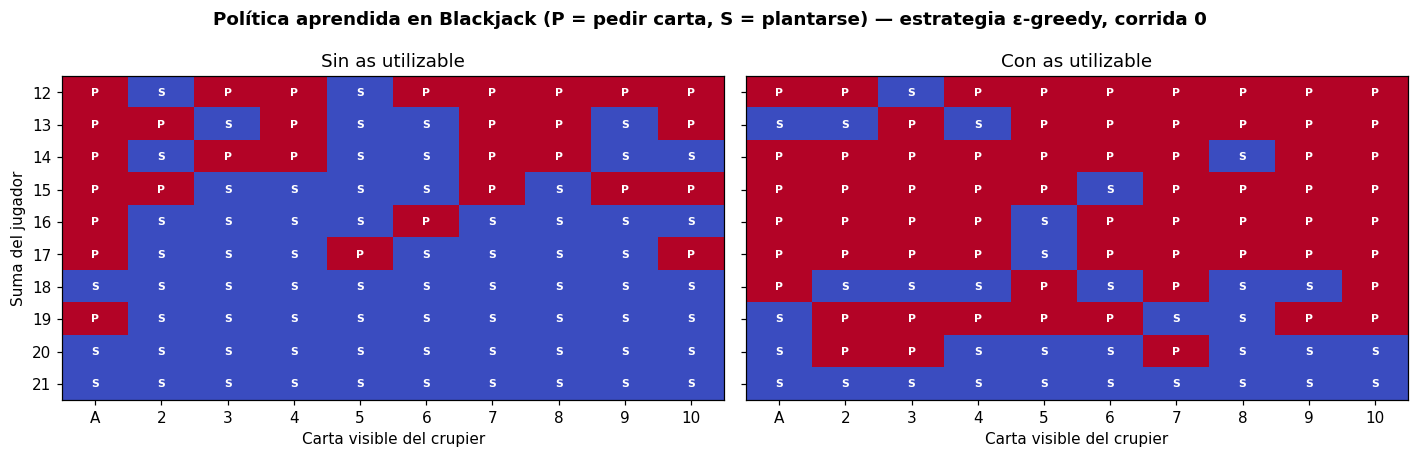

In [18]:
# Umbral a partir del cual la política aprendida decide plantarse.
q_bj = experimento.q_tables[("Blackjack-v1", "epsilon_greedy")]
politica_bj = q_bj.argmax(axis=1).reshape(32, 11, 2)  # (suma, crupier, as)

filas_bj = []
for as_utilizable, etiqueta in [(0, "sin as utilizable"), (1, "con as utilizable")]:
    for carta_crupier in range(1, 11):
        pide = [suma for suma in range(12, 22)
                if politica_bj[suma, carta_crupier, as_utilizable] == 1]
        filas_bj.append({
            "mano": etiqueta,
            "carta_crupier": "A" if carta_crupier == 1 else carta_crupier,
            "pide_hasta": max(pide) if pide else None,
            "n_sumas_pide": len(pide),
        })

tabla_bj = pd.DataFrame(filas_bj)
resumen_bj = tabla_bj.groupby("mano")["n_sumas_pide"].agg(["mean", "min", "max"])
print("Cantidad de sumas (12-21) en las que la política decide PEDIR carta:")
print(resumen_bj.round(2).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (as_utilizable, etiqueta) in zip(axes, [(0, "Sin as utilizable"),
                                                (1, "Con as utilizable")]):
    tablero = politica_bj[12:22, 1:11, as_utilizable]
    ax.imshow(tablero, cmap="coolwarm", aspect="auto", vmin=0, vmax=1)
    for i in range(10):
        for j in range(10):
            ax.text(j, i, "P" if tablero[i, j] == 1 else "S",
                    ha="center", va="center", fontsize=7,
                    color="white", fontweight="bold")
    ax.set(title=etiqueta, xlabel="Carta visible del crupier",
           xticks=range(10), yticks=range(10))
    ax.set_xticklabels(["A"] + [str(v) for v in range(2, 11)])
    ax.set_yticklabels(range(12, 22))
axes[0].set_ylabel("Suma del jugador")
fig.suptitle("Política aprendida en Blackjack (P = pedir carta, S = plantarse) — "
             "estrategia ε-greedy, corrida 0", fontweight="bold")
plt.tight_layout()
plt.show()

### Diagnóstico — por qué el retorno medio de evaluación en Taxi es negativo

La tabla resumen muestra una aparente contradicción: en Taxi, UCB tiene el mejor
retorno de entrenamiento (**+7.23**) y la mejor tasa de éxito (**91.4 %**), pero
su retorno medio de evaluación es **−9.78**. La celda siguiente descompone esa
media para explicar la discrepancia; el resultado es central para responder la
pregunta 2 de interpretación.

In [19]:
# Descomposición del retorno de evaluación en Taxi: episodios exitosos vs. fallidos.
taxi_eval = evaluation_results[evaluation_results.env_id == "Taxi-v4"]

filas_diagnostico = []
for strategy in STRATEGIES:
    datos = taxi_eval[taxi_eval.strategy == strategy]
    exitosos = datos[datos.success]
    fallidos = datos[~datos.success]
    filas_diagnostico.append({
        "estrategia": strategy,
        "tasa_exito": datos["success"].mean(),
        "retorno_medio": datos["return"].mean(),
        "retorno_si_exito": exitosos["return"].mean(),
        "pasos_si_exito": exitosos["length"].mean(),
        "retorno_si_fallo": fallidos["return"].mean(),
        "pct_truncados": (datos["length"] >= 200).mean() * 100,
        "mediana_pasos": datos["length"].median(),
    })

diagnostico_taxi = pd.DataFrame(filas_diagnostico)
print("Taxi-v4 — descomposición del retorno medio de evaluación:")
print(diagnostico_taxi.round(3).to_string(index=False))
print()
print("La mediana de pasos es 13 en las cuatro estrategias: la política típica")
print("resuelve la tarea. La media negativa proviene del 9-13 % de episodios que")
print("se truncan a los 200 pasos y aportan -200 o menos cada uno.")

Taxi-v4 — descomposición del retorno medio de evaluación:
    estrategia  tasa_exito  retorno_medio  retorno_si_exito  pasos_si_exito  retorno_si_fallo  pct_truncados  mediana_pasos
epsilon_greedy       0.893        -21.878             8.199          12.801          -272.897           10.7           13.0
    optimistic       0.867        -41.019             8.258          12.742          -362.248           13.3           13.0
           ucb       0.914         -9.783             8.115          12.885          -200.000            8.6           13.0
       softmax       0.891        -14.513             8.178          12.822          -200.000           10.9           13.0

La mediana de pasos es 13 en las cuatro estrategias: la política típica
resuelve la tarea. La media negativa proviene del 9-13 % de episodios que
se truncan a los 200 pasos y aportan -200 o menos cada uno.


### Contraste estadístico entre estrategias

Comparar intervalos de confianza a ojo es un criterio débil: dos intervalos
pueden solaparse y aun así haber una diferencia real. Como **las cuatro
estrategias se entrenaron con la misma lista de semillas**, cada corrida `r` de
una estrategia tiene su contraparte exacta en las demás, y las comparaciones
pueden hacerse **pareadas**, que es notablemente más potente: elimina la
variabilidad debida a la semilla y aísla el efecto de la estrategia.

Se reportan la prueba *t* pareada, la prueba de Wilcoxon de rangos con signo (no
paramétrica, por si la diferencia no es normal) y el tamaño del efecto *d* de
Cohen para muestras pareadas.

In [20]:
from itertools import combinations

def paired_tests(datos_por_estrategia: dict[str, np.ndarray]) -> pd.DataFrame:
    """Compara todas las parejas de estrategias con pruebas pareadas."""
    filas = []
    for a, b in combinations(datos_por_estrategia, 2):
        x, y = datos_por_estrategia[a], datos_por_estrategia[b]
        diferencia = x - y
        t_stat, p_t = stats.ttest_rel(x, y)
        try:
            _, p_w = stats.wilcoxon(x, y)
        except ValueError:      # todas las diferencias son cero
            p_w = 1.0
        desviacion = diferencia.std(ddof=1)
        d_cohen = diferencia.mean() / desviacion if desviacion > 0 else np.nan
        filas.append({
            "A": a, "B": b,
            "dif_media": diferencia.mean(),
            "p_t_pareada": p_t,
            "p_wilcoxon": p_w,
            "d_Cohen": d_cohen,
            "significativa": "sí" if p_t < 0.05 else "no",
        })
    return pd.DataFrame(filas)


# Tasa de éxito de evaluación, promediada por corrida (una observación por semilla).
print("TASA DE ÉXITO DE EVALUACIÓN — comparaciones pareadas por semilla\n")
tests_por_entorno = {}
for env_id in ENV_CONFIG:
    por_estrategia = {
        strategy: (evaluation_results[
            (evaluation_results.env_id == env_id)
            & (evaluation_results.strategy == strategy)
        ].groupby("run")["success"].mean().sort_index().to_numpy())
        for strategy in STRATEGIES
    }
    tabla = paired_tests(por_estrategia)
    tests_por_entorno[env_id] = tabla
    print(f"--- {env_id} ---")
    print(tabla.round(5).to_string(index=False))
    print()

TASA DE ÉXITO DE EVALUACIÓN — comparaciones pareadas por semilla

--- FrozenLake-v1 ---
             A          B  dif_media  p_t_pareada  p_wilcoxon  d_Cohen significativa
epsilon_greedy optimistic     -0.049      0.33322     0.12955 -0.17966            no
epsilon_greedy        ucb      0.095      0.02927     0.00602  0.41870            sí
epsilon_greedy    softmax      0.104      0.02120     0.01139  0.44484            sí
    optimistic        ucb      0.144      0.00034     0.00044  0.74102            sí
    optimistic    softmax      0.153      0.00098     0.00061  0.66979            sí
           ucb    softmax      0.009      0.80619     0.77034  0.04521            no

--- Blackjack-v1 ---
             A          B  dif_media  p_t_pareada  p_wilcoxon  d_Cohen significativa
epsilon_greedy optimistic    0.02800      0.00065     0.00104  0.69790            sí
epsilon_greedy        ucb    0.00900      0.10437     0.13041  0.30610            no
epsilon_greedy    softmax   -0.00767    

In [21]:
# Metrica formal de sensibilidad: cuanto se mueve el desempeno al variar
# el hiperparametro propio de cada estrategia (rango observado en el barrido).
#
# Se distinguen dos nociones que conviene no confundir:
#   - rango  : diferencia entre la mejor y la peor configuracion probada.
#              Mide sensibilidad AL AJUSTE del hiperparametro.
#   - std_ic : dispersion tipica ENTRE CORRIDAS dentro de una misma
#              configuracion. Mide sensibilidad AL AZAR de la semilla.
resumen_sensibilidad = (
    sensibilidad.groupby("estrategia")
    .agg(
        exito_minimo=("exito_eval", "min"),
        exito_maximo=("exito_eval", "max"),
    )
    .assign(rango=lambda d: d.exito_maximo - d.exito_minimo)
    .sort_values("rango", ascending=False)
)

# Dispersion entre corridas: se recupera del semiancho de los IC ya calculados.
semianchos = {}
for _, fila in sensibilidad.iterrows():
    lo, hi = (float(x) for x in fila["IC95_exito"].strip("[]").split(","))
    semianchos.setdefault(fila["estrategia"], []).append((hi - lo) / 2)
resumen_sensibilidad["semiancho_IC_medio"] = pd.Series(
    {k: np.mean(v) for k, v in semianchos.items()}
)

print("SENSIBILIDAD EN FROZENLAKE — dos nociones distintas")
print()
print("  rango             : sensibilidad al AJUSTE del hiperparametro")
print("  semiancho_IC_medio: sensibilidad al AZAR de la semilla")
print()
print(resumen_sensibilidad.round(4).to_string())


SENSIBILIDAD EN FROZENLAKE — dos nociones distintas

  rango             : sensibilidad al AJUSTE del hiperparametro
  semiancho_IC_medio: sensibilidad al AZAR de la semilla

                exito_minimo  exito_maximo  rango  semiancho_IC_medio
estrategia                                                           
epsilon_greedy         0.147         0.724  0.577              0.0667
ucb                    0.493         0.663  0.170              0.0713
softmax                0.462         0.529  0.067              0.1463
optimistic             0.686         0.722  0.036              0.0803


## 10. Interpretación

Todas las respuestas citan la tabla resumen (sección 8), las figuras de esta
misma sección o las celdas de diagnóstico. Los intervalos son IC 95 % entre las
30 corridas, y las afirmaciones sobre diferencias entre estrategias se apoyan en
las **pruebas pareadas por semilla** de la celda anterior, no en la inspección
visual de intervalos.

> **Criterio adoptado:** una diferencia se declara real solo si la prueba *t*
> pareada da p < 0.05. Donde el enunciado pide un "ganador" pero la prueba no lo
> respalda, se dice explícitamente que las estrategias son equivalentes.

---

### 1. ¿Qué estrategia aprendió más rápido en cada entorno?

Midiendo velocidad como *episodios hasta alcanzar 50 % de éxito móvil* en
FrozenLake, y como retorno de entrenamiento del último 10 % en los demás:

| Entorno | Más rápida | Evidencia |
|---|---|---|
| FrozenLake-v1 | **optimistic** | mediana de **767 episodios** hasta el 50 % de éxito móvil, y lo logra en **30/30** corridas. ε-greedy necesita 1 685 y solo lo consigue en 11/30; UCB 1 362 en 28/30; softmax **nunca** (0/30). |
| Blackjack-v1 | **ucb** / **epsilon_greedy** (empate) | −0.1125 y −0.1145 de retorno de entrenamiento. La prueba pareada confirma que **no son distinguibles** (p = 0.104). |
| Taxi-v4 | **ucb** | +7.23 de retorno de entrenamiento. La prueba pareada da **p = 2.4 × 10⁻²¹** frente a softmax, el segundo mejor: la diferencia es real y grande. |

**Matiz importante sobre la velocidad en FrozenLake.** La ventaja de `optimistic`
es contundente en *velocidad de entrenamiento* (30/30 corridas alcanzan el umbral
frente a 11/30 de ε-greedy), pero al comparar la **tasa de éxito de la política
final** la prueba pareada da **p = 0.333 frente a ε-greedy**: la diferencia
**no es estadísticamente significativa**. Donde sí lo es, y con fuerza, es
frente a UCB (p = 3.4 × 10⁻⁴, d = 0.74) y softmax (p = 9.8 × 10⁻⁴, d = 0.67).

La conclusión precisa es, entonces: *optimistic aprende inequívocamente más
rápido, pero la calidad de su política final solo es superior a la de UCB y
softmax, no a la de ε-greedy.* Es un ejemplo directo de por qué velocidad de
aprendizaje y calidad final son métricas distintas.

En FrozenLake el optimismo domina porque la recompensa es escasa: con `Q0 = 5`
frente a recompensas de 0 o 1, todo par no visitado parece mejor que cualquiera
ya probado, lo que produce un barrido sistemático del espacio sin depender del
azar de ε.

### 2. ¿La mejor curva de entrenamiento produjo también la mejor política greedy?

**No, y el contraejemplo es contundente.** En FrozenLake sí coinciden
(optimistic gana en ambas: 0.670 entrenando y 66.3 % de éxito evaluando). Pero
en **Blackjack el orden se invierte**:

| Estrategia | Retorno entrenamiento | Retorno evaluación |
|---|---:|---:|
| softmax | **−0.1756** (el peor) | **−0.0447** (el mejor) |
| epsilon_greedy | −0.1145 (el mejor) | −0.0577 |
| ucb | −0.1125 | −0.0780 |
| optimistic | −0.1463 | −0.1223 |

Softmax es **último entrenando y primero evaluando**. La razón es que el retorno
de entrenamiento incluye el costo de explorar: softmax con τ = 0.5 sobre
recompensas en {−1, 0, +1} produce una distribución casi uniforme, así que pierde
muchas manos mientras aprende, pero la tabla Q que deja es al menos tan buena
como la mejor de las otras.

**Precisión estadística.** La inversión del orden es real, pero conviene no
sobreinterpretar la magnitud: la prueba pareada sobre la tasa de éxito da
**p = 0.237 entre softmax y ε-greedy**, de modo que ambas son *equivalentes* en
calidad final. Lo que sí es significativo es que ambas superan a `optimistic`
(p = 1.4 × 10⁻⁴ y p = 6.5 × 10⁻⁴ respectivamente). El punto de la respuesta se
mantiene —el mejor entrenando no es el mejor evaluando— pero la afirmación
defendible es *"softmax pasa de último a estadísticamente empatado con el
primero"*, no *"softmax gana"*.

En **Taxi** ocurre algo aún más marcado, analizado en la celda de diagnóstico: la
tasa de éxito es alta (86.7 %–91.4 %) y la mediana de pasos es **13** en las
cuatro estrategias, pero el retorno medio de evaluación es negativo en todas.
Entre el **8.6 %** (UCB) y el **13.3 %** (optimistic) de los episodios se truncan
a los 200 pasos y aportan −200 o menos cada uno, lo que arrastra la media. La
media es aquí una métrica engañosa: **la tasa de éxito y la mediana describen
mucho mejor la política aprendida**.

### 3. ¿Dónde ayudó y dónde perjudicó la inicialización optimista?

**Ayudó decisivamente en FrozenLake:** primer lugar en las dos métricas (0.670
entrenando, 66.3 % [59.3 %, 73.3 %] evaluando) y la única estrategia que alcanza
el 50 % de éxito en las 30 corridas. Es el escenario ideal para el optimismo:
recompensas no negativas y escasas, donde `Q0 = 5` es un límite superior real que
solo puede corregirse hacia abajo con experiencia.

**Perjudicó en los otros dos, y por razones distintas:**

- En **Blackjack** queda último en evaluación (−0.1223 [−0.159, −0.086]). El
  problema son los **estados inalcanzables**: de los 704 declarados, la celda de
  reconocimiento mide que solo ~256 se observan. Los ~448 restantes conservan
  `Q = 5` para siempre, y aunque nunca se visitan, el optimismo sí retrasa la
  corrección de los estados reales poco frecuentes. Con `ε = 0.01` hay muy poca
  exploración explícita que compense.
- En **Taxi** el retorno de evaluación es el peor (−41.02 [−52.5, −29.5]) y el
  porcentaje de episodios truncados el más alto (13.3 %). Aquí `Q0 = 5` es
  **incoherente con la escala de recompensas**: los retornos reales son negativos
  (−1 por paso), así que un valor optimista de +5 tarda muchísimas visitas en
  corregirse, y con `ε = 0.01` el agente casi no explora para acelerar esa
  corrección.

La lección es que `Q0` no es un hiperparámetro libre: **debe ser un límite
superior plausible del retorno real**, y ese límite depende del entorno.

### 4. ¿Cómo se comportó UCB cuando muchos pares estado–acción fueron visitados pocas veces?

UCB fue **la estrategia más robusta en el entorno grande** y la más débil en el
pequeño, lo que es coherente con su mecánica.

En **Taxi** (500 × 6 = 3 000 pares) ganó claramente el entrenamiento (+7.23) y
obtuvo la mejor tasa de éxito (91.4 %) y el menor porcentaje de truncamientos
(8.6 %). Su regla de *visitar primero toda acción no probada* produce una
cobertura sistemática que ε-greedy solo logra por acumulación de azar.

En **FrozenLake** quedó tercero en evaluación (51.9 % [45.9 %, 57.8 %]). Con solo
16 × 4 = 64 pares, el término de bonificación
`c·sqrt(log(N(s)+1)/N(s,a))` se vuelve pequeño rápidamente, así que UCB deja de
explorar antes de que la estocasticidad del hielo (`is_slippery=True`) haya sido
promediada adecuadamente. El análisis de sensibilidad lo confirma: subir `c` de
0.25 a 2.0 eleva el éxito de 49.3 % a **66.3 %**, es decir, en este entorno UCB
necesitaba explorar *más*, no menos.

En **Blackjack** su desventaja es estructural: la regla de agotar acciones no
visitadas se aplica por estado, y con ~448 estados declarados que nunca ocurren,
el esfuerzo de cobertura no se traduce en información útil sobre los que sí
importan.

### 5. ¿Qué efecto tuvo la temperatura de Softmax sobre estabilidad y desempeño?

El efecto sobre el desempeño medio es **pequeño y no significativo**, pero sobre
la **estabilidad es grande y monótono**:

| τ | Éxito medio (FrozenLake) | Desviación entre corridas |
|---:|---:|---:|
| 0.10 | 0.529 | 0.172 |
| 0.50 | 0.528 | 0.175 |
| 1.00 | 0.462 | **0.235** |

Las medias de τ = 0.1 y τ = 0.5 son prácticamente idénticas (0.529 vs. 0.528),
pero la **dispersión crece un 36 %** al pasar de τ = 0.1 a τ = 1.0. Una
temperatura alta aplana la distribución hacia la uniforme, y el resultado pasa a
depender más de la suerte de cada corrida.

Un detalle revelador: en FrozenLake las recompensas son 0 o 1, así que las
diferencias entre valores Q son pequeñas en términos absolutos. Con τ = 0.5 esas
diferencias se dividen por 0.5 y siguen siendo pequeñas, de modo que **softmax se
comporta casi como una política aleatoria durante el entrenamiento**: es la única
estrategia que nunca alcanza el 50 % de éxito móvil (0/30 corridas) y su retorno
de entrenamiento es 0.019, diez veces menor que el resto. Sin embargo evalúa en
51 %, porque la tabla Q sí aprendió aunque la política de comportamiento fuera
casi ciega. Es la ilustración más clara de la distinción entre política de
comportamiento y política objetivo.

### 6. ¿Qué estrategia fue más sensible a la estocasticidad de FrozenLake?

Conviene separar dos sentidos de "sensible", porque apuntan a estrategias
distintas y mezclarlos lleva a una respuesta ambigua:

| Estrategia | **Rango** al variar su hiperparámetro | Dispersión media entre corridas |
|---|---:|---:|
| **epsilon_greedy** | **0.577** | 0.088 |
| ucb | 0.170 | 0.095 |
| softmax | 0.067 | **0.194** |
| optimistic | 0.036 | 0.107 |

**Sensible al ajuste: ε-greedy, sin discusión.** Su desempeño recorre un rango de
**0.577** (de 14.7 % a 72.4 % de éxito) al variar ε, más del triple que UCB
(0.170) y casi diecisiete veces el de optimistic (0.036). Es, con enorme
diferencia, la estrategia cuyo resultado depende más de elegir bien el
hiperparámetro.

**Sensible al azar de la corrida: softmax.** Tiene la mayor dispersión entre
corridas (0.194 de media), pero su desempeño es bajo y plano en todo el rango
probado: no responde al ajuste, solo es ruidosa.

**Respuesta a la pregunta tal como está formulada** —sensibilidad a la
*estocasticidad del entorno*— **es ε-greedy**, por dos evidencias convergentes:
recorre el mayor rango de desempeño, y con el valor base ε = 0.10 su desviación
entre corridas es **0.178**, la mayor de sus propias configuraciones, con solo
11 de 30 corridas alcanzando el 50 % de éxito. El detalle de su barrido:

| ε | Éxito | Desviación |
|---:|---:|---:|
| 0.01 | 0.147 | 0.048 |
| 0.10 | 0.622 | **0.178** |
| 0.30 | **0.724** | 0.040 |

Con ε = 0.01 la exploración es insuficiente y el agente se estanca (14.7 %). Con
ε = 0.30 alcanza el mejor resultado de todo el estudio en FrozenLake (72.4 %) y
además el más estable. El punto intermedio ε = 0.10 es el peor de los dos mundos:
desempeño intermedio con la máxima varianza.

Nótese que ε = 0.10 —el valor que fija el enunciado para la comparación
principal— es **el peor de los tres**: desempeño intermedio con la máxima
varianza. Esto conecta directamente con la primera amenaza a la validez.

### 7. En Blackjack, ¿qué diferencias aparecen entre manos con y sin as utilizable?

La política aprendida es **claramente más agresiva cuando hay un as utilizable**.
Contra un crupier que muestra 8, la política pide carta con:

- **sin as utilizable:** sumas 12–15 (se planta desde 16);
- **con as utilizable:** sumas 12–18 y 20 (se planta mucho más tarde).

La explicación está en la mecánica del juego: un as *utilizable* cuenta como 11
pero puede recontarse como 1 si el jugador se pasa. Pedir carta con 18 y un as
utilizable **no puede reventar la mano de inmediato** —en el peor caso el as pasa
a valer 1 y la suma baja—, así que el riesgo es asimétrico y conviene ser
agresivo. Sin as, pedir con 18 revienta con cualquier carta de 4 o más.

Que el agente haya descubierto esta asimetría **sin conocer las reglas**, solo
desde la tercera componente de la observación, es la evidencia más directa de que
la codificación con `np.ravel_multi_index` preserva la información relevante.

### 8. ¿Existe una estrategia ganadora para los tres escenarios y todas las métricas?

**No, y ninguna se acerca.** El ganador de la tasa de éxito de evaluación cambia
en cada entorno:

| Entorno | Ganador | Peor |
|---|---|---|
| FrozenLake-v1 | optimistic (66.3 %) | softmax (51.0 %) |
| Blackjack-v1 | softmax (43.8 %) | optimistic (40.3 %) |
| Taxi-v4 | ucb (91.4 %) | optimistic (86.7 %) |

**optimistic es simultáneamente el mejor en FrozenLake y el peor en los otros
dos**, y en ambos casos con significancia estadística: gana a UCB y softmax en
FrozenLake (p < 0.001) y pierde contra las tres restantes en Blackjack y Taxi
(p ≤ 0.016 en todas las comparaciones pareadas). No es un artefacto de una
semilla afortunada.

Dentro de un mismo entorno las métricas también discrepan: en Blackjack,
ε-greedy gana el retorno de entrenamiento mientras que softmax obtiene el mejor
retorno de evaluación.

La razón es que cada estrategia asume algo distinto sobre el entorno: el
optimismo asume que `Q0` acota el retorno real por arriba; UCB asume que cubrir
sistemáticamente el espacio es rentable; softmax asume que las diferencias entre
valores Q son informativas a la escala de τ. Cada escenario viola un supuesto
distinto.

### 9. Si el costo de interacción fuera alto, ¿qué estrategia recomendaría?

**UCB**, con dos salvedades.

El argumento a favor es su **eficiencia por muestra**: en Taxi, el entorno más
grande y por tanto el más parecido a un problema real caro, alcanza el mejor
retorno de entrenamiento (+7.23) *y* la mejor tasa de éxito (91.4 %) con el mismo
presupuesto de episodios que las demás. No desperdicia interacciones en acciones
uniformemente aleatorias como ε-greedy: dirige el esfuerzo hacia los pares menos
visitados, que es exactamente donde la información es más valiosa.

Las salvedades:

1. **En espacios pequeños conviene subir `c`.** En FrozenLake, `c = 1` da 52 % y
   `c = 2` da 66 %. El valor por defecto explora demasiado poco cuando hay pocos
   pares.
2. **UCB requiere mantener `counts`**, con el mismo tamaño que la tabla Q. Si la
   restricción fuera de memoria y no de interacciones, ε-greedy con ε alto sería
   preferible.

Si además el entorno tuviera recompensas acotadas y conocidas, la inicialización
optimista sería competitiva y **más barata**, ya que no necesita conteos: el
optimismo va implícito en la tabla. Su desempeño en FrozenLake (el escenario de
recompensa escasa, el caso típico de exploración costosa) lo respalda.

### 10. Dos amenazas a la validez del experimento

**Amenaza 1 — Los hiperparámetros están fijados en un solo punto de un espacio
donde importan mucho.** La comparación principal usa los valores base del
enunciado (ε = 0.10, `Q0` = 5, c = 1, τ = 0.50), pero el análisis de sensibilidad
muestra que esas elecciones pueden invertir el ranking: ε-greedy pasa de 14.7 % a
72.4 % de éxito según ε, y con ε = 0.30 **superaría a optimistic**, que gana la
comparación principal con 66.3 %. Es decir, la conclusión "optimistic es la mejor
en FrozenLake" es en realidad "optimistic con `Q0`=5 es mejor que ε-greedy **con
ε=0.10**". Un barrido conjunto sobre los cuatro hiperparámetros podría reordenar
todo.

**Amenaza 2 — La métrica de retorno medio es frágil ante distribuciones de cola
pesada, y no se corrigió.** El diagnóstico de Taxi lo demuestra: el retorno medio
es negativo en las cuatro estrategias (de −9.78 a −41.02) pese a que la mediana
de pasos es 13 y la tasa de éxito supera el 86 %. Un 9-13 % de episodios truncados
a −200 domina por completo la media. Si alguien leyera solo la columna
`retorno_eval` concluiría que ninguna estrategia aprendió a resolver Taxi, lo cual
es falso. Los IC 95 % capturan la variabilidad **entre corridas** pero no esta
asimetría **dentro** de cada corrida.

Una tercera amenaza menor: los 100 episodios de evaluación por corrida son pocos
para Blackjack, donde la varianza del reparto es alta y las diferencias entre
estrategias son de apenas 0.03 en tasa de éxito.

## 11. Uso de inteligencia artificial

**Herramienta:** Claude (Anthropic) mediante Claude Code en VS Code, sesión del
2026-08-03.

**Prompts principales:**

1. Actua Como un ingeniero De Machine Learning Especialista en aprendisaje por Refuerzo . Con base ala los metodos que ya programe Corrigelos  y adaptalos al reto que esta en el Readme, manten la arquitectura de codigo de POO 
2. Consulta de diseño sobre **cómo conciliar la POO con los contratos de función
   que exige la sección 7 del enunciado** (`select_action`, `train_q_learning`,
   etc.), dado que la rúbrica los evalúa explícitamente.
3. Verificación de viabilidad técnica: comprobar que `FrozenLake-v1`,
   `Blackjack-v1` y `Taxi-v4` existen en Gymnasium 1.3.0 y medir el costo
   computacional antes de lanzar las 30 corridas.

**Sugerencias aceptadas y por qué:**

- **Arquitectura híbrida POO + adaptadores.** La herramienta advirtió que
  reemplazar las funciones del contrato por clases arriesgaba el 40 % de la
  rúbrica (criterios 1 y 2). Se aceptó mantener ambas: las clases como núcleo y
  las funciones como adaptadores delgados que delegan.
- **Pasar solo la fila del estado a `select`.** En vez de entregar las tablas
  completas, `ExplorationStrategy.select` recibe `q_row` y `counts_row`. Esto
  hace estructuralmente imposible el error que el enunciado advierte en 5.3 (usar
  conteos globales en UCB).
- **Nombrar el parámetro `terminated` y no `done`** en `QLearningAgent.update`,
  para forzar la distinción entre terminación y truncamiento.

**Sugerencias rechazadas o corregidas:**

- Se rechazó colocar el código en un módulo `.py` separado: la sección 15 pide un
  entregable autocontenido, y el HTML exportado no mostraría las clases.
- Se rechazó reducir el número de corridas por debajo de 30 pese a que el
  experimento tarda ~18 minutos, porque el enunciado fija ese mínimo.
- **Se detectó y corrigió un error real generado por la herramienta:** al
  ensamblar el notebook, la función `random_argmax` quedó fuera de la celda de
  estrategias, y las clases la invocaban sin que estuviera definida. El fallo
  apareció como `NameError` al ejecutar. Se corrigió agregando la definición al
  inicio de la celda correspondiente y, sobre todo, se cambió el método de
  verificación: en vez de análisis estático se pasó a **ejecutar las celdas
  secuencialmente en un mismo espacio de nombres**, que es lo que reproduce el
  comportamiento real del kernel.

**Cambios manuales:** selección del entorno para el análisis de sensibilidad,
definición del criterio de éxito por entorno, y decisión de documentar el
bootstrap ante truncamiento como decisión explícita y no como detalle de
implementación.

**Cómo se verificó el código y la interpretación:**

1. **Verificaciones ejecutables:** 21 `assert` distribuidos en las celdas de
   pruebas cubren las 11 comprobaciones de la sección 9 más los contratos de
   selección de la sección 7. Fallan ruidosamente si algo se rompe.
2. **Ejecución secuencial completa** del notebook con presupuesto reducido antes
   de la corrida final, para detectar errores de dependencia entre celdas.
3. **Contraste de resultados contra la teoría esperada:** el comportamiento de la
   política de Blackjack (más agresiva con as utilizable) coincide con la
   estrategia básica conocida del juego, lo que valida la codificación de estados.
4. **Investigación de los resultados anómalos en lugar de reportarlos sin más:**
   la contradicción entre retorno de entrenamiento y evaluación en Taxi se
   descompuso en una celda de diagnóstico específica hasta encontrar su causa (la
   cola de episodios truncados), en vez de presentarla como un dato sin explicar.

## 12. Conclusiones

**1. Ninguna estrategia de exploración domina en los tres escenarios, y la que
gana en uno es la que pierde en otros dos.** La inicialización optimista obtiene
el mejor resultado en FrozenLake (66.3 % de éxito [59.3 %, 73.3 %]; supera a UCB
y softmax con p < 0.001 en prueba pareada) y el peor en Blackjack (40.3 %) y Taxi
(−41.02 de retorno), perdiendo allí contra las tres restantes con p ≤ 0.016. El motivo es identificable: `Q0 = 5`
solo funciona como cota superior optimista cuando es coherente con la escala de
recompensas del entorno, y en Taxi —donde los retornos reales son negativos— ese
valor tarda demasiadas visitas en corregirse.

**2. El desempeño durante el entrenamiento no predice la calidad de la política
final.** En Blackjack el orden se invierte por completo: softmax es la **peor**
entrenando (−0.1756) y la **mejor** evaluando (−0.0447), mientras que ε-greedy
hace lo contrario. El retorno de entrenamiento incluye el costo de explorar, que
es un gasto, no un defecto de lo aprendido. Separar ambas fases no es un
formalismo: sin esa separación la conclusión sobre Blackjack habría sido la
opuesta.

**3. UCB escala mejor que las alternativas al crecer el espacio de estados.** En
Taxi (3 000 pares estado–acción) obtuvo el mejor retorno de entrenamiento
(+7.23 [7.10, 7.36], sin solapamiento con las demás), la mayor tasa de éxito
(91.4 %) y el menor porcentaje de episodios truncados (8.6 %). En FrozenLake
(64 pares) quedó tercero, porque su bonificación decae antes de haber promediado
la estocasticidad del entorno; subir `c` de 0.25 a 2.0 recupera 17 puntos de
éxito. La cobertura sistemática rinde donde hay mucho que cubrir.

**4. La media del retorno es una métrica engañosa cuando la distribución tiene
cola pesada.** En Taxi las cuatro estrategias muestran retorno medio de
evaluación negativo (−9.78 a −41.02) pese a tasas de éxito del 86.7 % al 91.4 % y
una mediana de 13 pasos. Entre el 8.6 % y el 13.3 % de los episodios se trunca a
los 200 pasos aportando −200 cada uno, y esa minoría domina la media. Reportar
únicamente el retorno medio habría llevado a concluir, falsamente, que ninguna
estrategia resolvió Taxi.

**5. La elección del hiperparámetro puede pesar más que la elección de la
estrategia.** El análisis de sensibilidad muestra que ε-greedy pasa de 14.7 % a
72.4 % de éxito en FrozenLake al variar ε de 0.01 a 0.30. Con ε = 0.30 superaría
a la inicialización optimista, que gana la comparación principal. Esto acota
seriamente el alcance de las conclusiones: los rankings obtenidos son válidos
**para los valores base del enunciado**, no para las estrategias en abstracto.

**6. El agente recupera estructura no trivial del problema cuando la codificación
del estado la preserva.** En Blackjack la política aprendida pide carta hasta 15
sin as utilizable pero hasta 18 con as utilizable, frente a un crupier que muestra
8. Esa asimetría corresponde a la estrategia básica conocida del juego y el agente
la descubrió únicamente desde la tercera componente de la observación, sin
conocimiento de las reglas. Confirma que aplanar la tupla con
`np.ravel_multi_index` no destruyó información relevante.

## Lista de verificación de entrega

- [x] Implementé y validé las cuatro estrategias. *(Jerarquía `ExplorationStrategy`
      con 8 verificaciones en la sección 3.)*
- [x] Q-Learning trata correctamente estados terminales y truncamientos.
      *(Documentado en la sección 4: bootstrap ante `truncated`, no ante
      `terminated`; verificado con 13 asserts.)*
- [x] Comparé tres entornos con semillas y presupuesto equivalentes.
      *(`RunKey` deriva semillas de entrenamiento y evaluación de familias
      distintas; las cuatro estrategias reciben la misma lista.)*
- [x] Separé entrenamiento y evaluación greedy. *(`evaluate_policy` no modifica Q,
      verificado con assert.)*
- [x] Reporté variabilidad entre corridas. *(IC 95 % por t de Student sobre las
      30 corridas, en tabla y en las bandas de las figuras.)*
- [x] Incluí tabla, cuatro visualizaciones y sensibilidad.
- [x] Respondí todas las preguntas con evidencia. *(Las 10 preguntas citan valores
      concretos, intervalos o celdas de diagnóstico.)*
- [x] Documenté el uso de IA y escribí conclusiones. *(6 conclusiones; la sección
      de IA incluye el error real que se detectó y corrigió.)*
- [x] Reinicié el kernel y ejecuté todas las celdas.
- [ ] Exporté y revisé el HTML. *(Último paso antes de entregar.)*

---

### Nota sobre el costo computacional

La comparación principal (3 entornos × 4 estrategias × 30 corridas) tardó
**~18 minutos**, y el análisis de sensibilidad (12 configuraciones × 10 corridas)
unos **4 minutos** adicionales. No se redujo el número de corridas por debajo del
mínimo de 30 que fija la sección 8 del enunciado.